# Simulation / Loss Debugging

**Sections:** 1 Waveforms · 2 Stochastic vs Probabilistic · 3 Loss scan

In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats

project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)
%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import adc2charge
from larndsim.fee_jax import get_adc_values, digitize
from larndsim.sim_jax import simulate_wfs
from optimize.strategies import (LUTSimulation, LUTProbabilisticSimulation,
                                  ProbabilisticLossStrategy, LUTProbabilisticSamplingSimulation)
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges
import logging, optimize.strategies
logging.getLogger(optimize.strategies.__name__).setLevel(logging.WARNING)


/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
INPUT_FILE   = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE     = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS    = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS= 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab','kb','lifetime','tran_diff','long_diff','eField','shift_x','shift_y','shift_z']
ELECTRON_SAMPLING_RESOLUTION = 0.01
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params  = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params  = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH,
)
try:
    response, ref_params = load_lut(LUT_FILE, ref_params)
    print("LUT loaded.")
except Exception:
    response, ref_params = load_lut('src/larndsim/detector_properties/response_44.npy', ref_params)
    print("Fallback LUT loaded.")

initial_values  = {p: ranges[p]['nom'] for p in RELEVANT_PARAMS}
current_params  = ref_params.replace(**initial_values)
print("Parameters initialised.")


INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


LUT loaded.
Parameters initialised.


In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
dataset    = TracksDataset(filename=INPUT_FILE, nevents=-1,
                           electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=-1)
tracks_batch = dataloader[0]
track_fields = dataset.get_track_fields()
tracks = jax.device_put(tracks_batch.reshape(-1, len(track_fields)))
print(f"Loaded {tracks.shape[0]} track segments.")

# stoch_strategy = LUTProbabilisticSamplingSimulation(response)
stoch_strategy = LUTSimulation(response)
prob_strategy  = LUTProbabilisticSimulation(response)


INFO:optimize.dataio:-- The used simulation data includes a total track length of 3630936.6377038956 cm.
INFO:optimize.dataio:-- The number of simulation batches is 57890.


Loaded 24026 track segments.


---
## Section 1 — Waveform Visualisation

In [4]:
# Compute waveforms (no hit-finding yet)
wfs, unique_pixels = simulate_wfs(current_params, response, tracks, track_fields)
valid_mask = unique_pixels >= 0
valid_pixels = unique_pixels[valid_mask]
valid_wfs    = wfs[valid_mask]
print(f"Waveforms: {wfs.shape}  |  Valid pixels: {valid_mask.sum()}")


/usr/local/lib/python3.10/dist-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/detsim_jax.py:274: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in array is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.where(outside, jnp.array(-1, dtype=jnp.int64), pid)


Waveforms: (106, 2000)  |  Valid pixels: 94


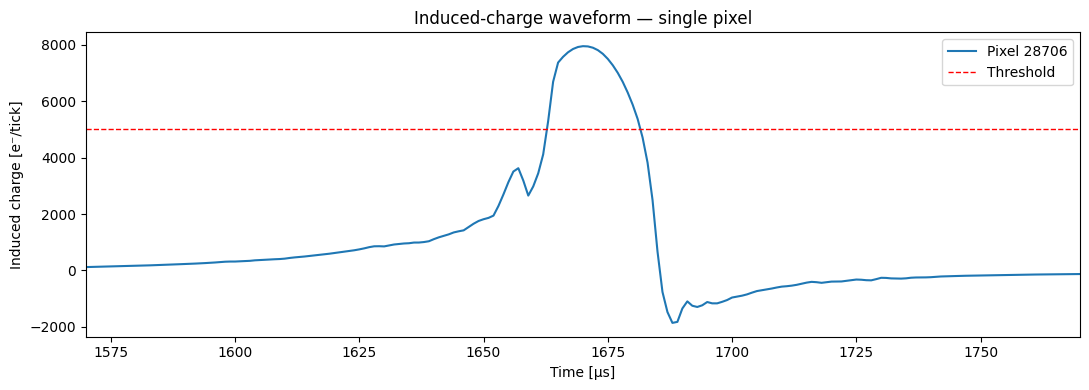

In [9]:
# ── Plot 1: Single pixel waveform ─────────────────────────────────────────────
PIXEL_IDX = 10          # change to inspect different pixels
Nticks = valid_wfs.shape[1]
ticks  = np.arange(Nticks)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ticks, np.array(valid_wfs[PIXEL_IDX]), lw=1.5, label=f'Pixel {int(valid_pixels[PIXEL_IDX])}')
ax.axhline(float(current_params.DISCRIMINATION_THRESHOLD),
           ls='--', color='red', lw=1, label='Threshold')
ax.set_xlabel('Time [µs]'); ax.set_ylabel('Induced charge [e⁻/tick]')
ax.set_title('Induced-charge waveform — single pixel')

peak = np.argmax(valid_wfs[PIXEL_IDX])
ax.set_xlim(peak - 100, peak+100)

ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ── Plot 1b: Zoom around peak ────────────────────────────────────────────────
peak_tick = np.argmax(np.array(valid_wfs[PIXEL_IDX]))
zoom_width = 10 / (float(current_params.t_sampling) * 1e6) 
t_start = max(0, int(peak_tick - zoom_width/2))
t_end   = min(Nticks, int(peak_tick + zoom_width/2))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ticks[t_start:t_end], np.array(valid_wfs[PIXEL_IDX][t_start:t_end]), marker='.', lw=1.5)
ax.axhline(float(current_params.DISCRIMINATION_THRESHOLD), ls='--', color='red', lw=1, label='Threshold')
ax.set_xlabel('Time [µs]'); ax.set_ylabel('Induced charge [e⁻/tick]')
ax.set_title(f'Zoom around peak — Pixel {int(valid_pixels[PIXEL_IDX])}')
ax.legend(); plt.tight_layout(); plt.show()

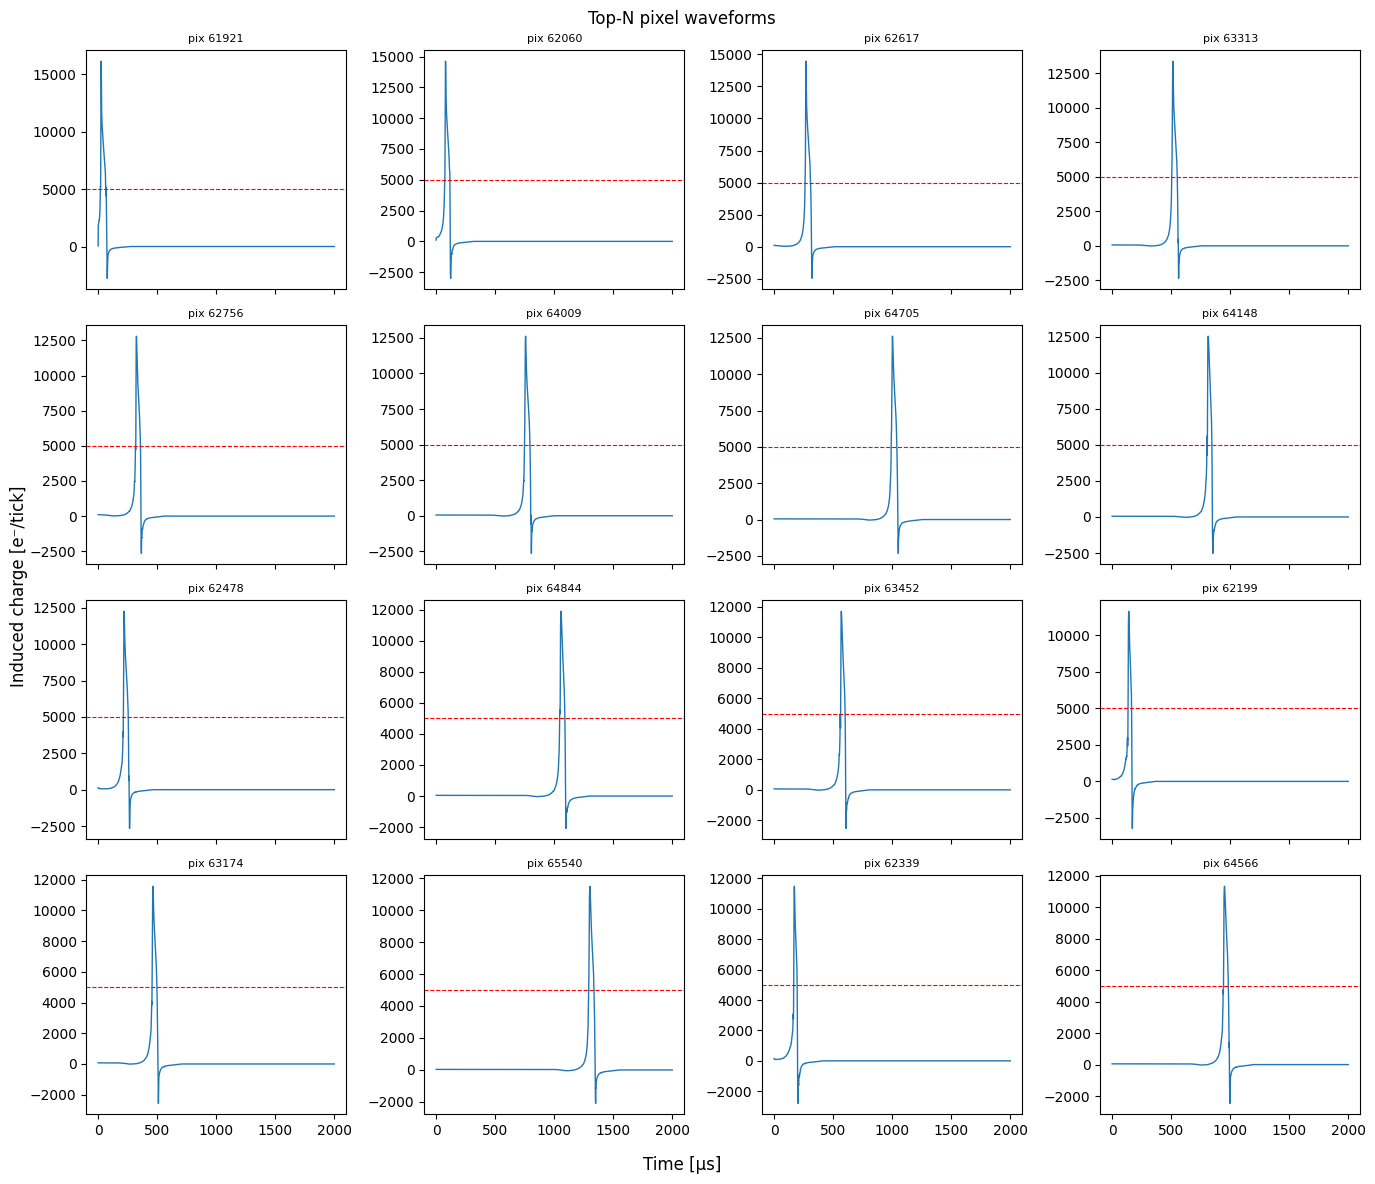

In [10]:
# ── Plot 2: Waveform gallery (N most-active pixels) ───────────────────────────
N_GALLERY = 16
peak_charge = np.array(valid_wfs).max(axis=1)
top_idx     = np.argsort(peak_charge)[::-1][:N_GALLERY]

ncols, nrows = 4, int(np.ceil(N_GALLERY / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows), sharex=True)
axes = axes.flat
for ax_i, pix_i in enumerate(top_idx):
    axes[ax_i].plot(ticks, np.array(valid_wfs[pix_i]), lw=1)
    axes[ax_i].axhline(float(current_params.DISCRIMINATION_THRESHOLD),
                       ls='--', color='red', lw=0.8)
    axes[ax_i].set_title(f'pix {int(valid_pixels[pix_i])}', fontsize=8)
for ax_i in range(len(top_idx), len(axes)): axes[ax_i].set_visible(False)
fig.supxlabel('Time [µs]'); fig.supylabel('Induced charge [e⁻/tick]')
fig.suptitle('Top-N pixel waveforms'); plt.tight_layout(); plt.show()


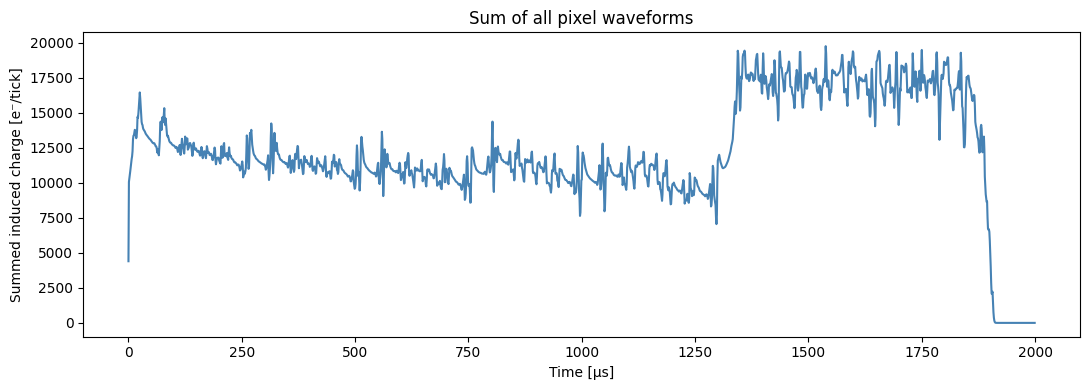

In [11]:
# ── Plot 3: Summed waveform ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ticks, np.array(valid_wfs).sum(axis=0), lw=1.5, color='steelblue')
ax.set_xlabel('Time [µs]'); ax.set_ylabel('Summed induced charge [e⁻/tick]')
ax.set_title('Sum of all pixel waveforms')
plt.tight_layout(); plt.show()


---
## Section 2 — Stochastic vs Probabilistic Validation

In [5]:
# Run probabilistic simulation
print("Running probabilistic simulation...")
prob_pred = prob_strategy.predict(current_params, tracks, track_fields, 42)
prob_unique_pixels = prob_pred['unique_pixels']
prob_wfs           = prob_pred['wfs']           # (Npix, Nticks)
hit_prob_log       = prob_pred['hit_prob']      # (Npix, Nhits, Nticks) – log-probs
adcs_distrib       = prob_pred['adcs_distrib']  # (Npix, Nhits, Nticks)
Npix_prob, Nhits, Nticks_prob = hit_prob_log.shape
print(f"Probabilistic: {Npix_prob} pixels, {Nhits} hit slots, {Nticks_prob} ticks")


Running probabilistic simulation...
Probabilistic: 128 pixels, 10 hit slots, 1999 ticks


In [6]:
# Run stochastic simulation (all hits, vmapped chunks)
N_STOCH   = 10_000
CHUNK_SZ  = 200
print(f"Running {N_STOCH} stochastic draws in chunks of {CHUNK_SZ}...")

@jax.jit
def run_chunk_all_hits(keys_chunk):
    vmapped = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmapped(current_params, prob_wfs, keys_chunk)
    adcs = digitize(current_params, integrals)
    return ticks, adcs  # (CHUNK_SZ, Npix, MAX_ADC_VALUES)

keys = jax.random.split(jax.random.PRNGKey(0), N_STOCH)
all_ticks_list, all_adcs_list = [], []
for i in tqdm(range(0, N_STOCH, CHUNK_SZ)):
    chunk_keys = keys[i:i+CHUNK_SZ]
    t, a = run_chunk_all_hits(chunk_keys)
    all_ticks_list.append(t)
    all_adcs_list.append(a)

stoch_ticks = jnp.concatenate(all_ticks_list, axis=0)  # (N_STOCH, Npix, MAX_ADC_VALUES)
stoch_adcs  = jnp.concatenate(all_adcs_list,  axis=0)
print(f"Stochastic draws shape: ticks={stoch_ticks.shape}, adcs={stoch_adcs.shape}")


Running 10000 stochastic draws in chunks of 200...


  0%|          | 0/50 [00:00<?, ?it/s]2026-04-30 02:07:36.128844: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 pad=0_0x0_0x15_0}, to_apply=%region_0.362

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-04-30 02:07:39.137728: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.009827249s
Constant folding an instruction is taking > 1s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 

Stochastic draws shape: ticks=(10000, 128, 10), adcs=(10000, 128, 10)


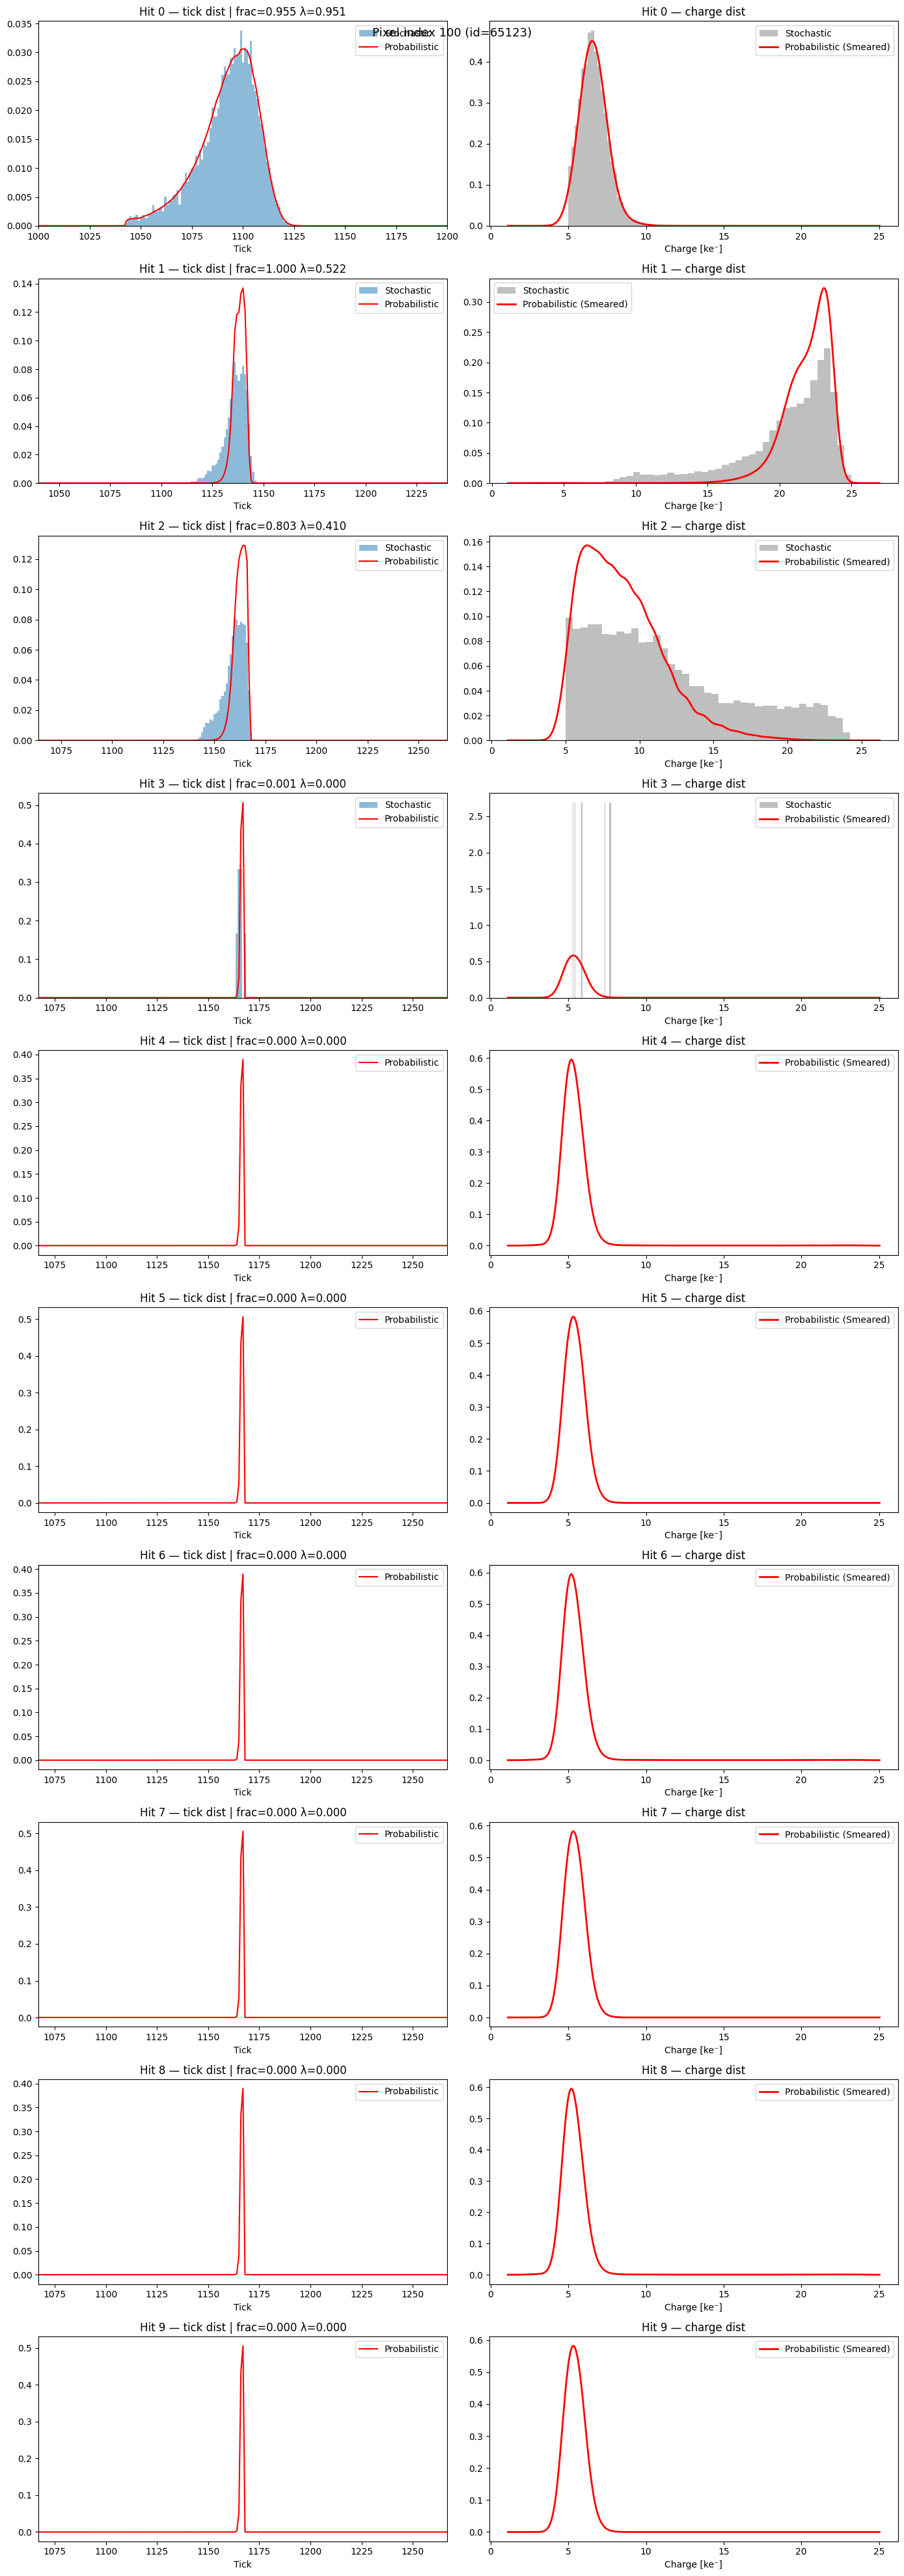

In [7]:
# ── Per-pixel, per-hit comparison ─────────────────────────────────────────────
TARGET_PIX_IDX = 100   # index into prob_unique_pixels; change to inspect others
VALID_TICK_BOUND = Nticks_prob - 3

fig, axes = plt.subplots(Nhits, 2, figsize=(14, 4*Nhits))
if Nhits == 1: axes = axes[np.newaxis, :]

from scipy.stats import norm

for hit_i in range(Nhits):
    # Stochastic ticks & adcs for this hit slot
    s_ticks = np.array(stoch_ticks[:, TARGET_PIX_IDX, hit_i])
    s_adcs  = np.array(stoch_adcs[:,  TARGET_PIX_IDX, hit_i])
    valid   = s_ticks < VALID_TICK_BOUND
    s_ticks_v = s_ticks[valid]
    s_adcs_v  = s_adcs[valid]

    # Probabilistic distributions
    p_log  = np.array(hit_prob_log[TARGET_PIX_IDX, hit_i, :])
    p_prob = np.exp(p_log)
    p_adc  = np.array(adcs_distrib[TARGET_PIX_IDX, hit_i, :])

    # ── Tick distribution ──────────────────────────────────────────────────
    ax = axes[hit_i, 0]
    
    # "One bin per tick" means integer bins centered on ticks
    # We use np.arange covering the full range for consistent bin widths
    tick_bins = np.arange(0, Nticks_prob + 1) - 0.5
    
    if len(s_ticks_v) > 0:
        ax.hist(s_ticks_v, bins=tick_bins, density=True, alpha=0.5, label='Stochastic')
    
    ax.plot(np.arange(Nticks_prob), p_prob / max(p_prob.sum(), 1e-30),
            'r-', lw=1.5, label='Probabilistic')
    
    # Zoom around peak (+- 200 ticks)
    # Find peak in probabilistic model (more stable)
    if p_prob.max() > 0:
        peak_t = np.argmax(p_prob)
        ax.set_xlim(max(0, peak_t - 100), min(Nticks_prob, peak_t + 100))
    
    hit_frac = valid.mean()
    lam      = p_prob.sum()
    ax.set_title(f'Hit {hit_i} — tick dist | frac={hit_frac:.3f} λ={lam:.3f}')
    ax.set_xlabel('Tick'); ax.legend()

    # ── Charge distribution ────────────────────────────────────────────────
    ax = axes[hit_i, 1]
    s_charge = np.array(adc2charge(s_adcs_v, current_params)) if len(s_adcs_v) else np.array([])
    p_charge = np.array(adc2charge(p_adc, current_params))
    
    if len(s_charge) > 0:
        ax.hist(s_charge, bins=40, density=True, alpha=0.5, label='Stochastic', color='gray')
    
    # Weighted sum of Gaussians for Probabilistic
    sigma_ke = float(current_params.UNCORRELATED_NOISE_CHARGE) / 1000.0
    
    # Determine plot range
    if len(s_charge) > 0:
        q_min = min(s_charge.min(), p_charge.min()) - 3*sigma_ke
        q_max = max(s_charge.max(), p_charge.max()) + 3*sigma_ke
    else:
        q_min = p_charge.min() - 3*sigma_ke
        q_max = p_charge.max() + 3*sigma_ke
    
    q_vals = np.linspace(q_min, q_max, 300)
    weights = p_prob / max(p_prob.sum(), 1e-30)
    
    # Vectorized PDF calculation for the mixture
    mixture_pdf = np.sum(weights[:, np.newaxis] * norm.pdf(q_vals[np.newaxis, :], 
                                                         loc=p_charge[:, np.newaxis], 
                                                         scale=sigma_ke), axis=0)
    
    ax.plot(q_vals, mixture_pdf, 'r-', lw=2, label='Probabilistic (Smeared)')
    
    ax.set_title(f'Hit {hit_i} — charge dist')
    ax.set_xlabel('Charge [ke⁻]'); ax.legend()

plt.suptitle(f'Pixel index {TARGET_PIX_IDX} (id={int(prob_unique_pixels[TARGET_PIX_IDX])})',
             fontsize=13)
plt.tight_layout(); plt.show()


In [76]:
# ── Aggregate validation metrics ──────────────────────────────────────────────
print(f"{'Pix':>5} {'Hit':>4} {'KS-tick':>9} {'|Δλ|':>8} {'λ_prob':>8} {'λ_stoch':>8}")
rows = []
for pix_i in range(min(Npix_prob, 1000)):          # cap at 20 pixels for display
    pid = int(prob_unique_pixels[pix_i])
    if pid < 0: continue
    for hit_i in range(Nhits):
        s_t   = np.array(stoch_ticks[:, pix_i, hit_i])
        valid = s_t < (Nticks_prob - 3)
        lam_s = valid.mean()
        p_log_slice = np.array(hit_prob_log[pix_i, hit_i, :])
        p_prob_slice = np.exp(p_log_slice)
        lam_p = p_prob_slice.sum()
        ks    = np.nan
        if valid.sum() > 20:
            hist_s, _ = np.histogram(s_t[valid], bins=Nticks_prob, range=(0, Nticks_prob), density=True)
            ks = stats.ks_2samp(hist_s, p_prob_slice / max(lam_p, 1e-30)).statistic
        rows.append((pid, hit_i, ks, abs(lam_p - lam_s), lam_p, lam_s))
        print(f"{pid:>5} {hit_i:>4} {ks:>9.4f} {abs(lam_p-lam_s):>8.4f} {lam_p:>8.4f} {lam_s:>8.4f}")


  Pix  Hit   KS-tick     |Δλ|   λ_prob  λ_stoch
28009    0    0.9630   0.0031   0.9997   0.9966
28009    1    0.9915   0.0255   0.1183   0.1438
28009    2       nan   0.0000   0.0000   0.0000
28009    3       nan   0.0000   0.0000   0.0000
28009    4       nan   0.0000   0.0000   0.0000
28009    5       nan   0.0000   0.0000   0.0000
28009    6       nan   0.0000   0.0000   0.0000
28009    7       nan   0.0000   0.0000   0.0000
28009    8       nan   0.0000   0.0000   0.0000
28009    9       nan   0.0000   0.0000   0.0000
28010    0    0.9715   0.0313   0.9666   0.9353
28010    1       nan   0.0001   0.0002   0.0003
28010    2       nan   0.0000   0.0000   0.0000
28010    3       nan   0.0000   0.0000   0.0000
28010    4       nan   0.0000   0.0000   0.0000
28010    5       nan   0.0000   0.0000   0.0000
28010    6       nan   0.0000   0.0000   0.0000
28010    7       nan   0.0000   0.0000   0.0000
28010    8       nan   0.0000   0.0000   0.0000
28010    9       nan   0.0000   0.0000  

---
## Section 3 — Loss Scanning

Four loss modes averaged over 500 stochastic draws.

In [13]:
from larndsim.detsim_jax import id2pixel, get_hit_z
from optimize.strategies import compute_occurrence_indices

def build_target_from_draw(ticks_draw, adcs_draw, prob_unique_pixels, current_params, Nticks):
    """
    Convert a single stochastic draw (Npix, MAX_ADC_VALUES) into a flat target dict
    compatible with ProbabilisticLossStrategy.compute().
    """
    Npix, Nhits_max = ticks_draw.shape
    _, _, pixel_plane, _ = id2pixel(current_params, prob_unique_pixels)

    hit_pixels_list, ticks_list, adcs_list, z_list = [], [], [], []
    for hit_i in range(Nhits_max):
        t  = ticks_draw[:, hit_i]
        a  = adcs_draw[:, hit_i]
        valid = (t < (Nticks - 3)) & (prob_unique_pixels >= 0)
        if valid.sum() == 0: continue
        pids = prob_unique_pixels[valid]
        planes = pixel_plane[valid]
        ti   = t[valid].astype(jnp.int32)
        z    = get_hit_z(current_params, ti, planes)
        hit_pixels_list.append(pids)
        ticks_list.append(ti)
        adcs_list.append(a[valid])
        z_list.append(z)

    if not hit_pixels_list:
        dummy = jnp.zeros(1, dtype=jnp.int32)
        return dict(hit_pixels=dummy-1, ticks=dummy, adcs=jnp.zeros(1),
                    pixel_z=jnp.zeros(1), pixel_x=dummy, pixel_y=dummy,
                    event=dummy, hit_prob=jnp.ones(1))

    hit_pixels = jnp.concatenate(hit_pixels_list)
    ticks_all  = jnp.concatenate(ticks_list)
    adcs_all   = jnp.concatenate(adcs_list)
    z_all      = jnp.concatenate(z_list)

    # Sort by pixel id for compute_occurrence_indices
    sort_idx    = jnp.argsort(hit_pixels)
    hit_pixels  = hit_pixels[sort_idx]
    ticks_all   = ticks_all[sort_idx]
    adcs_all    = adcs_all[sort_idx]
    z_all       = z_all[sort_idx]

    return dict(
        hit_pixels=hit_pixels,
        pixel_id=hit_pixels,
        ticks=ticks_all,
        adcs=adcs_all,
        pixel_z=z_all,
        pixel_x=jnp.zeros_like(ticks_all),   # not used by ProbabilisticLossStrategy
        pixel_y=jnp.zeros_like(ticks_all),
        event=jnp.zeros_like(ticks_all),
        hit_prob=jnp.ones_like(ticks_all, dtype=jnp.float32),
    )


In [78]:
# Define the four loss strategies
DEADTIME_TICKS = round(
    (3 * float(current_params.CLOCK_CYCLE) + float(current_params.ADC_HOLD_DELAY) * float(current_params.CLOCK_CYCLE))
    / float(current_params.t_sampling)
)
print(f"Deadtime ticks: {DEADTIME_TICKS}")

loss_strategies = {
    '1st hit only':          ProbabilisticLossStrategy(first_hit_only=True),
    'All hits':              ProbabilisticLossStrategy(first_hit_only=False),
    'All hits + deadtime':   ProbabilisticLossStrategy(first_hit_only=False,
                                                        apply_deadtime=True,
                                                        deadtime_ticks=DEADTIME_TICKS),
    'Smooth (Gaussian win)': ProbabilisticLossStrategy(first_hit_only=False,
                                                        time_window=2, sigma_time=1.0),
}


Deadtime ticks: 18


In [79]:
# Collect 500 stochastic draws (vmapped, chunked) and compute losses
N_LOSS_DRAWS = 500
LOSS_CHUNK   = 50
loss_keys    = jax.random.split(jax.random.PRNGKey(99), N_LOSS_DRAWS)

@jax.jit
def run_chunk_loss_draws(keys_chunk):
    vmapped = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmapped(current_params, prob_wfs, keys_chunk)
    adcs = digitize(current_params, integrals)
    return ticks, adcs   # (LOSS_CHUNK, Npix, MAX_ADC_VALUES)

loss_records = {name: [] for name in loss_strategies}
aux_records  = {name: [] for name in loss_strategies}

print("Scanning losses over stochastic draws...")
for chunk_start in tqdm(range(0, N_LOSS_DRAWS, LOSS_CHUNK)):
    chunk_keys = loss_keys[chunk_start:chunk_start+LOSS_CHUNK]
    t_chunk, a_chunk = run_chunk_loss_draws(chunk_keys)
    # Python loop only at chunk granularity
    for draw_i in range(t_chunk.shape[0]):
        target = build_target_from_draw(
            t_chunk[draw_i], a_chunk[draw_i],
            prob_unique_pixels, current_params, Nticks_prob
        )
        for name, strategy in loss_strategies.items():
            nll, aux = strategy.compute(current_params, prob_pred, target)
            loss_records[name].append(float(nll))
            aux_records[name].append({k: float(v) for k, v in aux.items()})

print("Done.")
for name, vals in loss_records.items():
    arr = np.array(vals)
    print(f"  {name:30s}  mean={arr.mean():.4f}  std={arr.std():.4f}")


Scanning losses over stochastic draws...


  0%|          | 0/10 [00:00<?, ?it/s]2026-04-30 01:10:40.727984: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 4s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 pad=0_0x0_0x15_0}, to_apply=%region_0.362

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-04-30 01:10:40.792406: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.064513778s
Constant folding an instruction is taking > 4s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 

Done.
  1st hit only                    mean=536.3612  std=16.5712
  All hits                        mean=1154.0107  std=53.2601
  All hits + deadtime             mean=1136.3380  std=49.3134
  Smooth (Gaussian win)           mean=1154.0107  std=53.2601


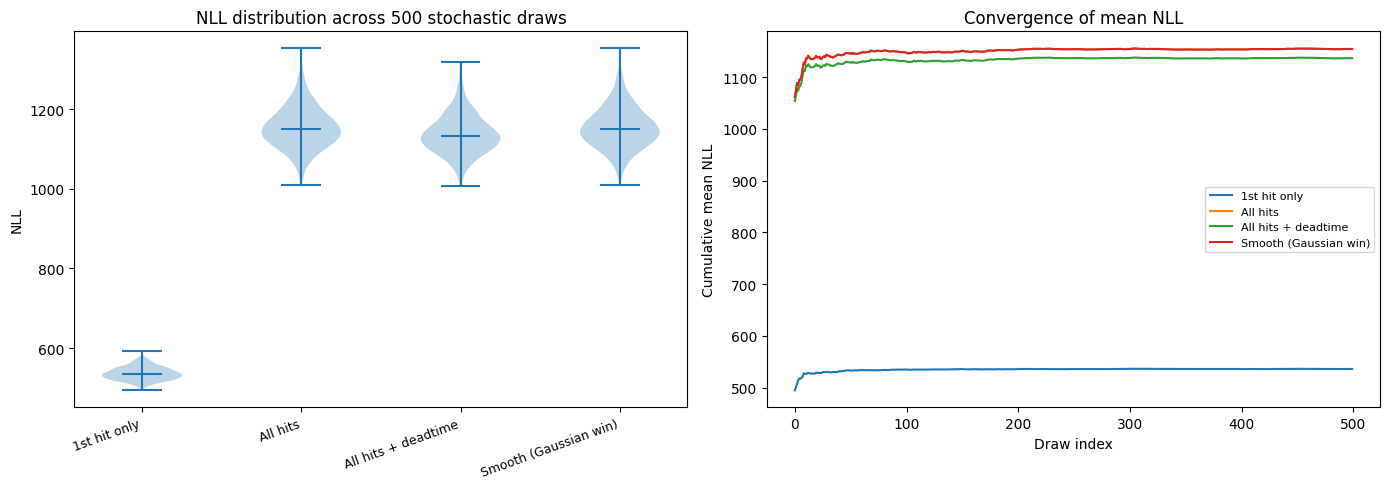

In [80]:
# ── Plot: NLL distribution per loss mode ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(loss_records.keys())
data  = [np.array(loss_records[n]) for n in names]

# Violin plot
vp = axes[0].violinplot(data, showmedians=True, showextrema=True)
axes[0].set_xticks(range(1, len(names)+1))
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('NLL'); axes[0].set_title('NLL distribution across 500 stochastic draws')

# Loss vs draw index
for name, arr in zip(names, data):
    running = np.cumsum(arr) / (np.arange(len(arr)) + 1)
    axes[1].plot(running, label=name, lw=1.5)
axes[1].set_xlabel('Draw index'); axes[1].set_ylabel('Cumulative mean NLL')
axes[1].set_title('Convergence of mean NLL'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


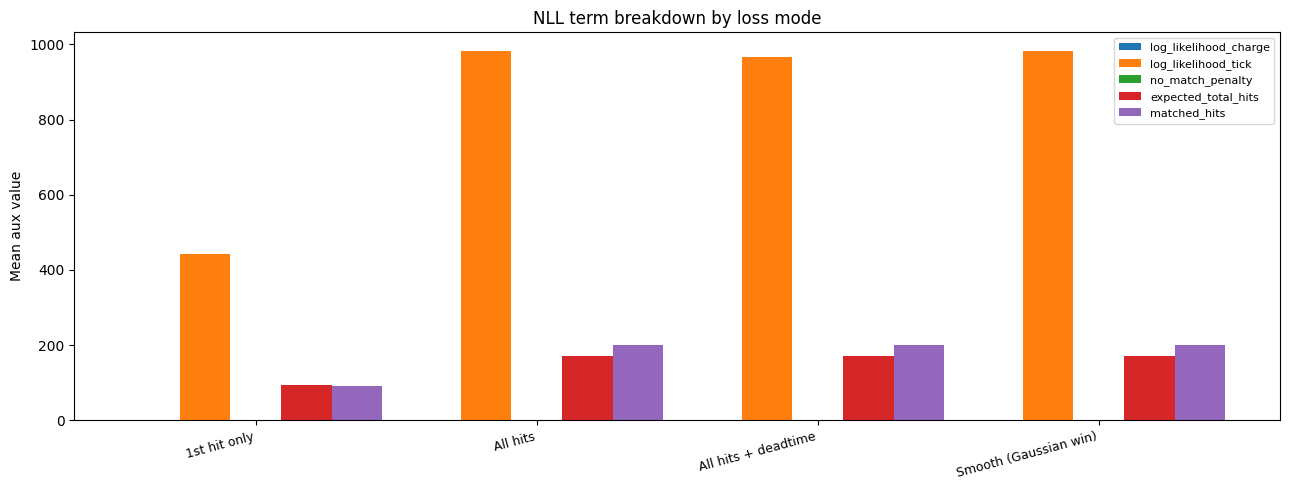

In [38]:
# ── Plot: Aux term breakdown ──────────────────────────────────────────────────
aux_keys = list(aux_records[names[0]][0].keys())
x = np.arange(len(names))
width = 0.18
fig, ax = plt.subplots(figsize=(13, 5))
for k_i, key in enumerate(aux_keys):
    means = [np.mean([r[key] for r in aux_records[n]]) for n in names]
    ax.bar(x + k_i*width, means, width, label=key)
ax.set_xticks(x + width*(len(aux_keys)-1)/2)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Mean aux value'); ax.set_title('NLL term breakdown by loss mode')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [39]:
# ── Optional: gradient w.r.t. lifetime ────────────────────────────────────────
# Pick the first valid target draw for gradient check
target_for_grad = build_target_from_draw(
    stoch_ticks[0], stoch_adcs[0], prob_unique_pixels, current_params, Nticks_prob
)

def nll_vs_lifetime(lifetime_val, strategy):
    p = current_params.replace(lifetime=lifetime_val)
    # Re-run probabilistic simulation
    from larndsim.fee_jax import get_adc_values_average_noise_vmap
    log_prob, adc_d = get_adc_values_average_noise_vmap(p, prob_wfs)
    pred_local = dict(prob_pred, hit_prob=log_prob, adcs_distrib=adc_d)
    nll, _ = strategy.compute(p, pred_local, target_for_grad)
    return nll

print("Computing lifetime gradients (may compile ~30s)...")
nom_lt = float(current_params.lifetime)
for name, strategy in loss_strategies.items():
    grad_fn = jax.grad(nll_vs_lifetime)
    g = float(grad_fn(nom_lt, strategy))
    print(f"  {name:30s}  dNLL/d(lifetime) = {g:.6f}")


Computing lifetime gradients (may compile ~30s)...
  1st hit only                    dNLL/d(lifetime) = 0.000000
  All hits                        dNLL/d(lifetime) = 0.000000
  All hits + deadtime             dNLL/d(lifetime) = 0.000000
  Smooth (Gaussian win)           dNLL/d(lifetime) = 0.000000


---
### Loss scan as a function of a configurable parameter

For each value of `SCAN_PARAM` in a defined grid, we:
1. Re-run the probabilistic simulation with the updated parameter
2. Generate N stochastic draws (vmapped) from the **nominal** waveforms as target data
3. Compute the mean NLL over those draws for each loss mode

This shows the curvature and bias of each loss strategy as a function of the chosen parameter, using the nominal (true) waveforms as data.

In [81]:
# ── Scan configuration ────────────────────────────────────────────────────────
# ┌─ ONLY LINE TO CHANGE ──────────────────────────────────────────────────────┐
SCAN_PARAM   = 'kb'      # any key in `ranges` dict, e.g. 'kb', 'eField', 'lifetime'
# └────────────────────────────────────────────────────────────────────────────┘

N_SCAN_PTS   = 50        # number of parameter values to scan
N_SCAN_DRAWS = 500       # stochastic draws per point (fixed data, reused across all points)
SCAN_CHUNK   = 50        # vmap chunk size for draw generation

param_nom = float(getattr(current_params, SCAN_PARAM))
param_min = ranges[SCAN_PARAM]['min']
param_max = ranges[SCAN_PARAM]['max']
param_vals = np.linspace(param_min, param_max, N_SCAN_PTS)

print(f"Scanning '{SCAN_PARAM}'  in [{param_min:.4g}, {param_max:.4g}]  (nominal={param_nom:.4g})")

# Pre-generate stochastic target draws from the NOMINAL waveforms.
# These are fixed "data"; only the prediction changes with the scanned parameter.
print(f"\nGenerating {N_SCAN_DRAWS} stochastic target draws from nominal waveforms...")
scan_keys = jax.random.split(jax.random.PRNGKey(777), N_SCAN_DRAWS)

@jax.jit
def run_scan_chunk(keys_chunk):
    vmapped = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmapped(current_params, prob_wfs, keys_chunk)
    adcs = digitize(current_params, integrals)
    return ticks, adcs

scan_ticks_list, scan_adcs_list = [], []
for i in tqdm(range(0, N_SCAN_DRAWS, SCAN_CHUNK), desc="Target draws"):
    t, a = run_scan_chunk(scan_keys[i:i+SCAN_CHUNK])
    scan_ticks_list.append(t)
    scan_adcs_list.append(a)
scan_ticks = np.concatenate([np.array(x) for x in scan_ticks_list], axis=0)  # (N_SCAN_DRAWS, Npix, Nhits)
scan_adcs  = np.concatenate([np.array(x) for x in scan_adcs_list],  axis=0)
print(f"Done. scan_ticks.shape = {scan_ticks.shape}")

# Pre-build all target dicts (one per draw) – done once, reused for every parameter value
print("Building target dicts...")
scan_targets = [
    build_target_from_draw(
        jnp.array(scan_ticks[k]), jnp.array(scan_adcs[k]),
        prob_unique_pixels, current_params, Nticks_prob
    )
    for k in range(N_SCAN_DRAWS)
]
print("Done.")


Scanning 'kb'  in [0.03, 0.08]  (nominal=0.0486)

Generating 500 stochastic target draws from nominal waveforms...


Target draws: 100%|██████████| 10/10 [00:06<00:00,  1.65it/s]


Done. scan_ticks.shape = (500, 128, 10)
Building target dicts...
Done.


In [82]:
# ── Run the parameter scan ────────────────────────────────────────────────────
# scan_results[strategy_name] → array (N_SCAN_PTS, 2)  columns: [mean_nll, sem_nll]
scan_results = {name: np.zeros((N_SCAN_PTS, 2)) for name in loss_strategies}

for pi, pv in enumerate(tqdm(param_vals, desc=f"{SCAN_PARAM} scan")):
    test_params = current_params.replace(**{SCAN_PARAM: float(pv)})

    # Re-run probabilistic simulation at this parameter value
    pred_pv = prob_strategy.predict(test_params, tracks, track_fields, 42)

    # Compute loss for each draw and each strategy
    nlls = {name: [] for name in loss_strategies}
    for target in scan_targets:
        for name, strategy in loss_strategies.items():
            nll, _ = strategy.compute(test_params, pred_pv, target)
            nlls[name].append(float(nll))

    for name in loss_strategies:
        arr = np.array(nlls[name])
        scan_results[name][pi, 0] = arr.mean()
        scan_results[name][pi, 1] = arr.std() / np.sqrt(len(arr))

print(f"'{SCAN_PARAM}' scan complete.")
for name in loss_strategies:
    best_pv = param_vals[np.argmin(scan_results[name][:, 0])]
    print(f"  {name:30s}  min-NLL {SCAN_PARAM} = {best_pv:.4g}  (nominal={param_nom:.4g})")


kb scan: 100%|██████████| 50/50 [20:47<00:00, 24.95s/it]

'kb' scan complete.
  1st hit only                    min-NLL kb = 0.05245  (nominal=0.0486)
  All hits                        min-NLL kb = 0.04735  (nominal=0.0486)
  All hits + deadtime             min-NLL kb = 0.04735  (nominal=0.0486)
  Smooth (Gaussian win)           min-NLL kb = 0.04735  (nominal=0.0486)


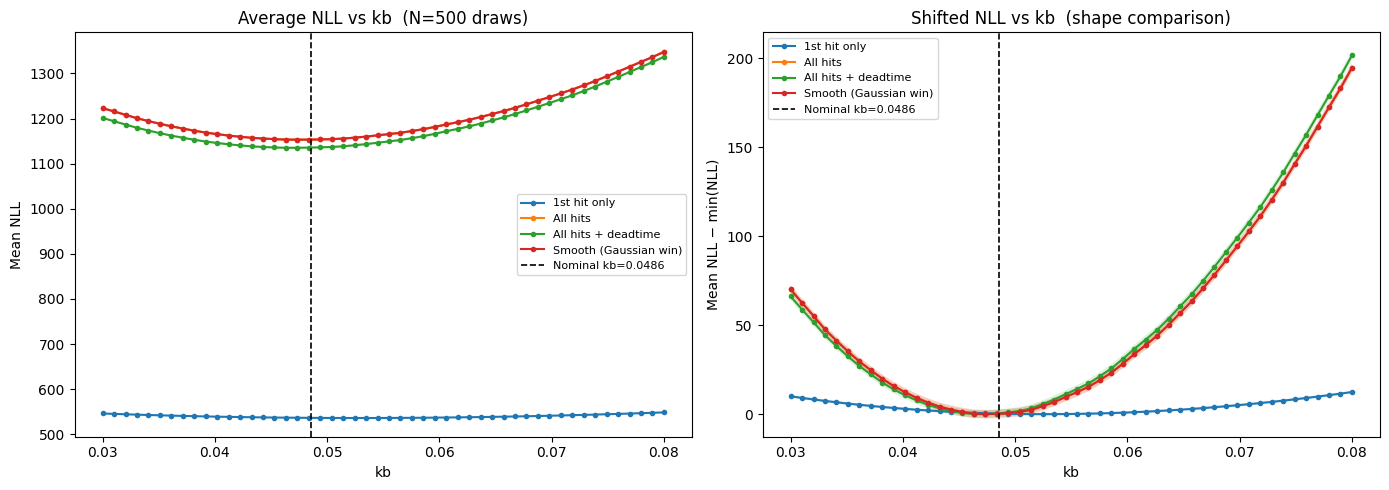

In [83]:
# ── Plot scan results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in scan_results.items():
    mean_nll = res[:, 0]
    sem_nll  = res[:, 1]
    mean_shifted = mean_nll - mean_nll.min()
    axes[0].plot(param_vals, mean_nll, marker='o', ms=3, lw=1.5, label=name)
    axes[1].plot(param_vals, mean_shifted, marker='o', ms=3, lw=1.5, label=name)
    axes[0].fill_between(param_vals, mean_nll - sem_nll, mean_nll + sem_nll, alpha=0.15)
    axes[1].fill_between(param_vals, mean_shifted - sem_nll, mean_shifted + sem_nll, alpha=0.15)

for ax in axes:
    ax.axvline(param_nom, ls='--', color='black', lw=1.2,
               label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
    ax.set_xlabel(SCAN_PARAM)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Mean NLL')
axes[0].set_title(f'Average NLL vs {SCAN_PARAM}  (N={N_SCAN_DRAWS} draws)')
axes[1].set_ylabel('Mean NLL − min(NLL)')
axes[1].set_title(f'Shifted NLL vs {SCAN_PARAM}  (shape comparison)')

plt.tight_layout()
plt.show()


---
### Section 3b — Bias Diagnosis: First-Hit Only

We decompose the NLL bias analytically for the first-hit case.

**The PPP NLL (first-hit) for a single pixel is:**
```
NLL_pix = - log p(t_obs | pix)           [tick term]
          - log p(Q_obs | t_obs, pix)     [charge term]
          + Σ_t exp(hit_prob[pix, 0, t])  [expected-hits term / false-positive penalty]
```

**Bias diagnostic approach:**
1. **Analytic expected NLL**: replace the stochastic draw with the exact probabilistic expectation → should be minimised at nominal kb if the model is consistent
2. **Separate tick vs charge vs expected-hits terms** to see which one drives the bias
3. **Per-pixel NLL contribution** to identify problematic pixels

In [84]:
# ── Analytic expected NLL vs scanned parameter (first-hit only) ───────────────
# Uses the EXACT probabilistic distribution as both prediction and "truth",
# eliminating stochastic noise. Should be exactly minimised at the nominal value
# if the model is internally consistent.
#
# E[NLL_pix] = -Σ_t p_nom(t) * log p_test(t)      [cross-entropy tick term]
#              -Σ_t p_nom(t) * log p_Q(Q_nom|t)    [cross-entropy charge term]
#              + Σ_t exp(hit_prob_test[pix, 0, t])  [expected-hits term]

strategy_1st = ProbabilisticLossStrategy(first_hit_only=True)
sigma_ke = strategy_1st.sigma_charge / 1000.0

# Nominal probabilistic simulation (already in prob_pred)
p_nom = jnp.exp(prob_pred['hit_prob'][:, 0, :])                            # (Npix, Nticks)
q_nom = adc2charge(prob_pred['adcs_distrib'][:, 0, :], current_params)     # (Npix, Nticks) ke-

print(f"Computing analytic expected NLL vs {SCAN_PARAM}...")
analytic_results = {'tick': [], 'charge': [], 'expected_hits': [], 'total': []}

valid_pix_mask = prob_unique_pixels >= 0

for pv in tqdm(param_vals, desc=f"Analytic scan ({SCAN_PARAM})"):
    test_params = current_params.replace(**{SCAN_PARAM: float(pv)})
    pred_pv     = prob_strategy.predict(test_params, tracks, track_fields, 42)

    log_p_test = pred_pv['hit_prob'][:, 0, :]                              # (Npix, Nticks)
    q_test     = adc2charge(pred_pv['adcs_distrib'][:, 0, :], test_params) # (Npix, Nticks) ke-

    p_nom_v      = np.array(p_nom[valid_pix_mask])
    log_p_test_v = np.array(log_p_test[valid_pix_mask])
    q_nom_v      = np.array(q_nom[valid_pix_mask])
    q_test_v     = np.array(q_test[valid_pix_mask])

    tick_term    = -np.sum(p_nom_v * log_p_test_v)
    charge_diff  = q_nom_v - q_test_v
    log_charge   = -0.5 * (charge_diff / sigma_ke)**2 - 0.5 * np.log(2 * np.pi * sigma_ke**2)
    charge_term  = -np.sum(p_nom_v * log_charge)
    exp_hits     = float(jnp.sum(jnp.exp(pred_pv['hit_prob'][:, 0, :])))

    analytic_results['tick'].append(tick_term)
    analytic_results['charge'].append(charge_term)
    analytic_results['expected_hits'].append(exp_hits)
    analytic_results['total'].append(tick_term + charge_term + exp_hits)

print("Done.")


Computing analytic expected NLL vs kb...


Analytic scan (kb): 100%|██████████| 50/50 [00:04<00:00, 11.39it/s]

Done.


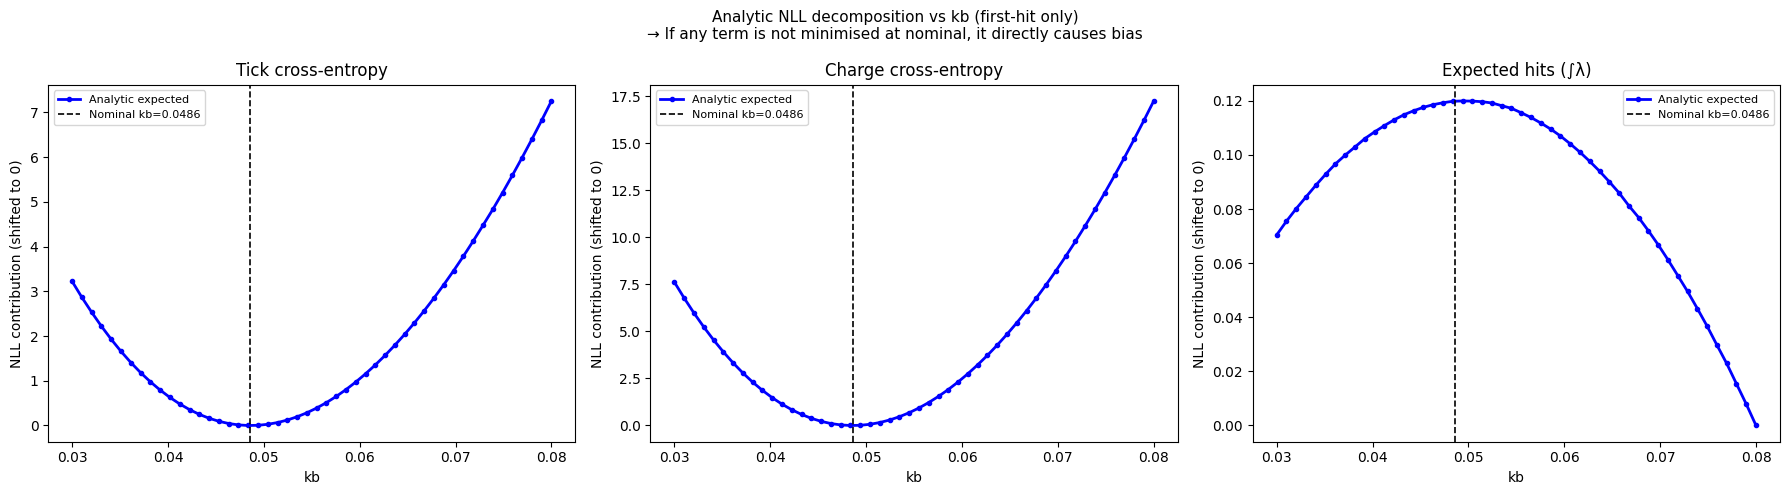

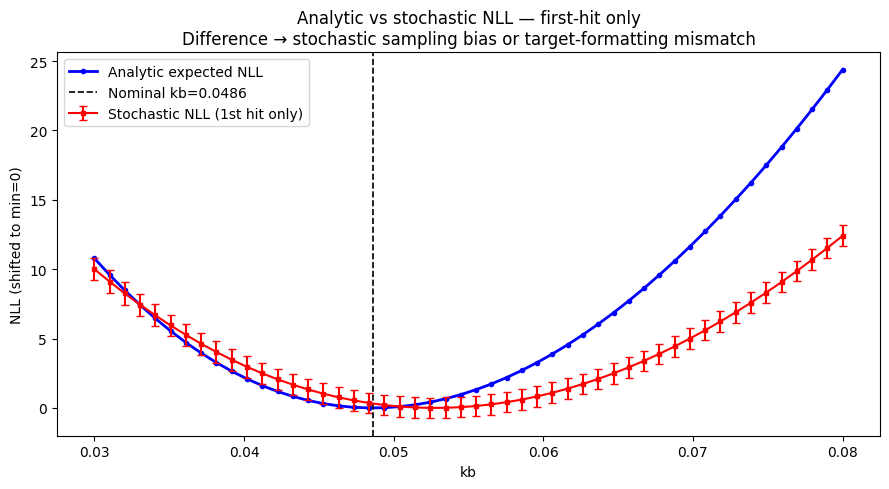

In [85]:
# ── Plot: Analytic NLL decomposition vs scanned parameter ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

terms  = ['tick', 'charge', 'expected_hits']
labels = ['Tick cross-entropy', 'Charge cross-entropy', 'Expected hits (∫λ)']

for ax, term, label in zip(axes, terms, labels):
    arr = np.array(analytic_results[term])
    ax.plot(param_vals, arr - arr.min(), 'b-o', ms=3, lw=2, label='Analytic expected')
    ax.axvline(param_nom, ls='--', color='black', lw=1.2,
               label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
    ax.set_xlabel(SCAN_PARAM)
    ax.set_ylabel('NLL contribution (shifted to 0)')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle(f'Analytic NLL decomposition vs {SCAN_PARAM} (first-hit only)\n'
             '→ If any term is not minimised at nominal, it directly causes bias', fontsize=11)
plt.tight_layout()
plt.show()

# Compare analytic total vs stochastic-averaged total
fig, ax = plt.subplots(figsize=(9, 5))
an_total    = np.array(analytic_results['total'])
an_shifted  = an_total - an_total.min()
ax.plot(param_vals, an_shifted, 'b-o', ms=3, lw=2, label='Analytic expected NLL')

# Overlay the first-hit stochastic scan if available
for candidate in ['1st hit only', 'first_hit', list(scan_results.keys())[0]]:
    if candidate in scan_results:
        stoch_mean    = scan_results[candidate][:, 0]
        stoch_sem     = scan_results[candidate][:, 1]
        stoch_shifted = stoch_mean - stoch_mean.min()
        ax.errorbar(param_vals, stoch_shifted, yerr=stoch_sem, fmt='rs-', ms=3,
                    lw=1.5, capsize=3, label=f'Stochastic NLL ({candidate})')
        break

ax.axvline(param_nom, ls='--', color='black', lw=1.2,
           label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
ax.set_xlabel(SCAN_PARAM)
ax.set_ylabel('NLL (shifted to min=0)')
ax.set_title(f'Analytic vs stochastic NLL — first-hit only\n'
             'Difference → stochastic sampling bias or target-formatting mismatch')
ax.legend()
plt.tight_layout()
plt.show()


Bias draws:   0%|          | 0/2 [00:00<?, ?it/s]2026-04-30 17:12:09.442859: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 4s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 pad=0_0x0_0x15_0}, to_apply=%region_0.362

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-04-30 17:12:09.503529: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.060759228s
Constant folding an instruction is taking > 4s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={s

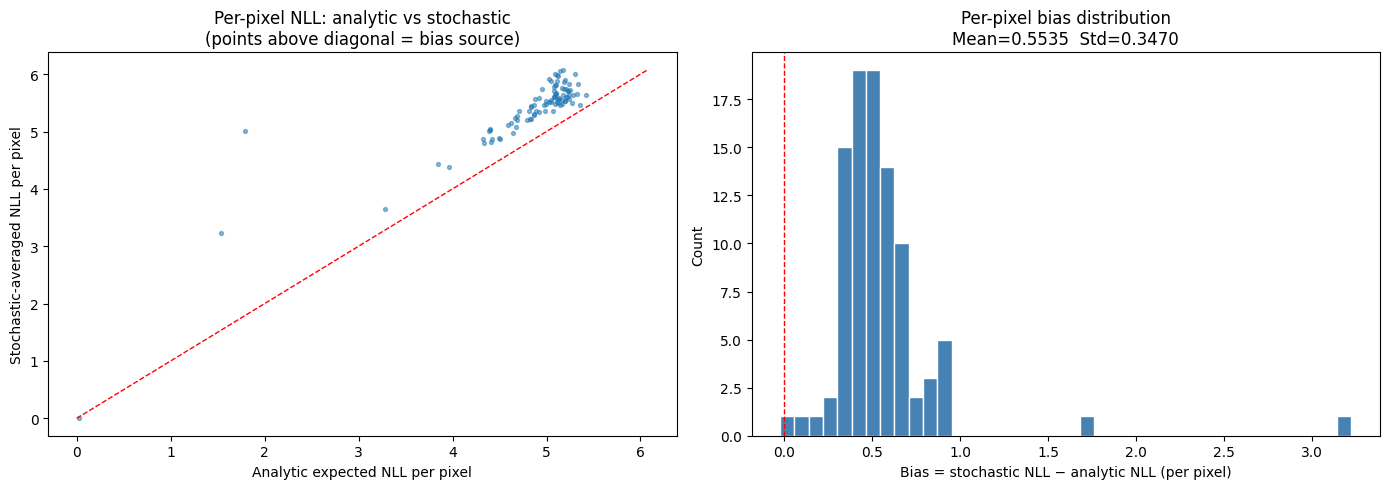

Top 10 pixels by |bias|:
  pix_id    λ_nom    analytic  stochastic      bias
   62061   0.4424      1.7908      5.0161    3.2253
   61781   0.4465      1.5360      3.2219    1.6859
   64983   0.9620      5.1410      6.0611    0.9201
   65401   0.9539      5.0857      6.0037    0.9180
   63869   0.9625      5.1792      6.0799    0.9007
   66514   0.9174      5.0260      5.9158    0.8898
   29123   0.9293      5.1142      5.9883    0.8741
   66375   0.9211      5.0510      5.8890    0.8380
   66096   0.9362      5.1267      5.9646    0.8380
   66792   0.9671      4.9498      5.7457    0.7959


In [31]:
# ── Per-pixel NLL bias decomposition at nominal kb ────────────────────────────
# For each pixel: compute the analytic expected NLL and the stochastic-averaged NLL.
# Large discrepancies identify pixels driving the global bias.

N_BIAS_DRAWS = 100   # fewer draws, just need to see the pattern
bias_keys    = jax.random.split(jax.random.PRNGKey(42), N_BIAS_DRAWS)

# Generate stochastic draws once at nominal kb
@jax.jit
def run_chunk_nom(keys_chunk):
    vmapped = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmapped(current_params, prob_wfs, keys_chunk)
    adcs = digitize(current_params, integrals)
    return ticks, adcs

bias_ticks_list, bias_adcs_list = [], []
for i in tqdm(range(0, N_BIAS_DRAWS, 50), desc="Bias draws"):
    t, a = run_chunk_nom(bias_keys[i:i+50])
    bias_ticks_list.append(np.array(t))
    bias_adcs_list.append(np.array(a))
bias_ticks = np.concatenate(bias_ticks_list, axis=0)   # (N_BIAS_DRAWS, Npix, Nhits)
bias_adcs  = np.concatenate(bias_adcs_list,  axis=0)

# For each pixel: analytic expected NLL contribution (first-hit only)
p_nom_np     = np.array(p_nom)     # (Npix, Nticks)
log_p_nom_np = np.array(prob_pred['hit_prob'][:, 0, :])  # (Npix, Nticks)
q_nom_np     = np.array(q_nom)     # (Npix, Nticks)

# Analytic per-pixel expected NLL at nominal (self-information = entropy)
analytic_tick_per_pix   = -np.sum(p_nom_np * log_p_nom_np, axis=1)   # (Npix,)
log_charge_self         = -0.5 * np.log(2 * np.pi * sigma_ke**2)      # constant (independent of t when Q_nom=Q_test)
analytic_charge_per_pix  = -np.sum(p_nom_np * log_charge_self, axis=1)
analytic_exphits_per_pix = np.sum(p_nom_np, axis=1)                   # Σ_t exp(log p) = λ_pix
analytic_nll_per_pix     = analytic_tick_per_pix + analytic_charge_per_pix + analytic_exphits_per_pix

# Stochastic per-pixel NLL over N_BIAS_DRAWS draws (first hit only, slot 0)
stoch_nll_per_pix = np.zeros(len(prob_unique_pixels))
for k in range(N_BIAS_DRAWS):
    t_draw = bias_ticks[k, :, 0]    # (Npix,)
    a_draw = bias_adcs[k,  :, 0]    # (Npix,)
    valid  = t_draw < (Nticks_prob - 3)
    for pix_i in np.where(valid)[0]:
        t_obs = int(t_draw[pix_i])
        a_obs = float(a_draw[pix_i])
        q_obs = float(adc2charge(jnp.array([a_obs]), current_params)[0])
        # Tick contribution
        log_p_t = log_p_nom_np[pix_i, t_obs]
        # Charge contribution
        log_p_q = -0.5 * ((q_obs - q_nom_np[pix_i, t_obs]) / sigma_ke)**2 - 0.5 * np.log(2*np.pi*sigma_ke**2)
        stoch_nll_per_pix[pix_i] += (-(log_p_t + log_p_q) + analytic_exphits_per_pix[pix_i]) / N_BIAS_DRAWS
    # Pixels with no hit: contribution is just the expected hits term (no tick/charge penalty)
    for pix_i in np.where(~valid)[0]:
        stoch_nll_per_pix[pix_i] += analytic_exphits_per_pix[pix_i] / N_BIAS_DRAWS

# Bias per pixel
bias_per_pix = stoch_nll_per_pix - analytic_nll_per_pix
valid_pix_mask = np.array(prob_unique_pixels) >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(analytic_nll_per_pix[valid_pix_mask], 
                stoch_nll_per_pix[valid_pix_mask], s=8, alpha=0.5)
lim = max(analytic_nll_per_pix[valid_pix_mask].max(), stoch_nll_per_pix[valid_pix_mask].max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlabel('Analytic expected NLL per pixel')
axes[0].set_ylabel('Stochastic-averaged NLL per pixel')
axes[0].set_title('Per-pixel NLL: analytic vs stochastic\n(points above diagonal = bias source)')

axes[1].hist(bias_per_pix[valid_pix_mask], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, ls='--', color='red', lw=1)
axes[1].set_xlabel('Bias = stochastic NLL − analytic NLL (per pixel)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Per-pixel bias distribution\n'
                  f'Mean={bias_per_pix[valid_pix_mask].mean():.4f}  '
                  f'Std={bias_per_pix[valid_pix_mask].std():.4f}')

plt.tight_layout()
plt.show()

# Top biased pixels
top_bias_idx = np.argsort(np.abs(bias_per_pix[valid_pix_mask]))[::-1][:10]
print("Top 10 pixels by |bias|:")
print(f"{'pix_id':>8}  {'λ_nom':>7}  {'analytic':>10}  {'stochastic':>10}  {'bias':>8}")
valid_indices = np.where(valid_pix_mask)[0]
for i in top_bias_idx:
    pix_i = valid_indices[i]
    pid   = int(prob_unique_pixels[pix_i])
    lam   = analytic_exphits_per_pix[pix_i]
    an    = analytic_nll_per_pix[pix_i]
    st    = stoch_nll_per_pix[pix_i]
    print(f"{pid:>8}  {lam:>7.4f}  {an:>10.4f}  {st:>10.4f}  {st-an:>8.4f}")


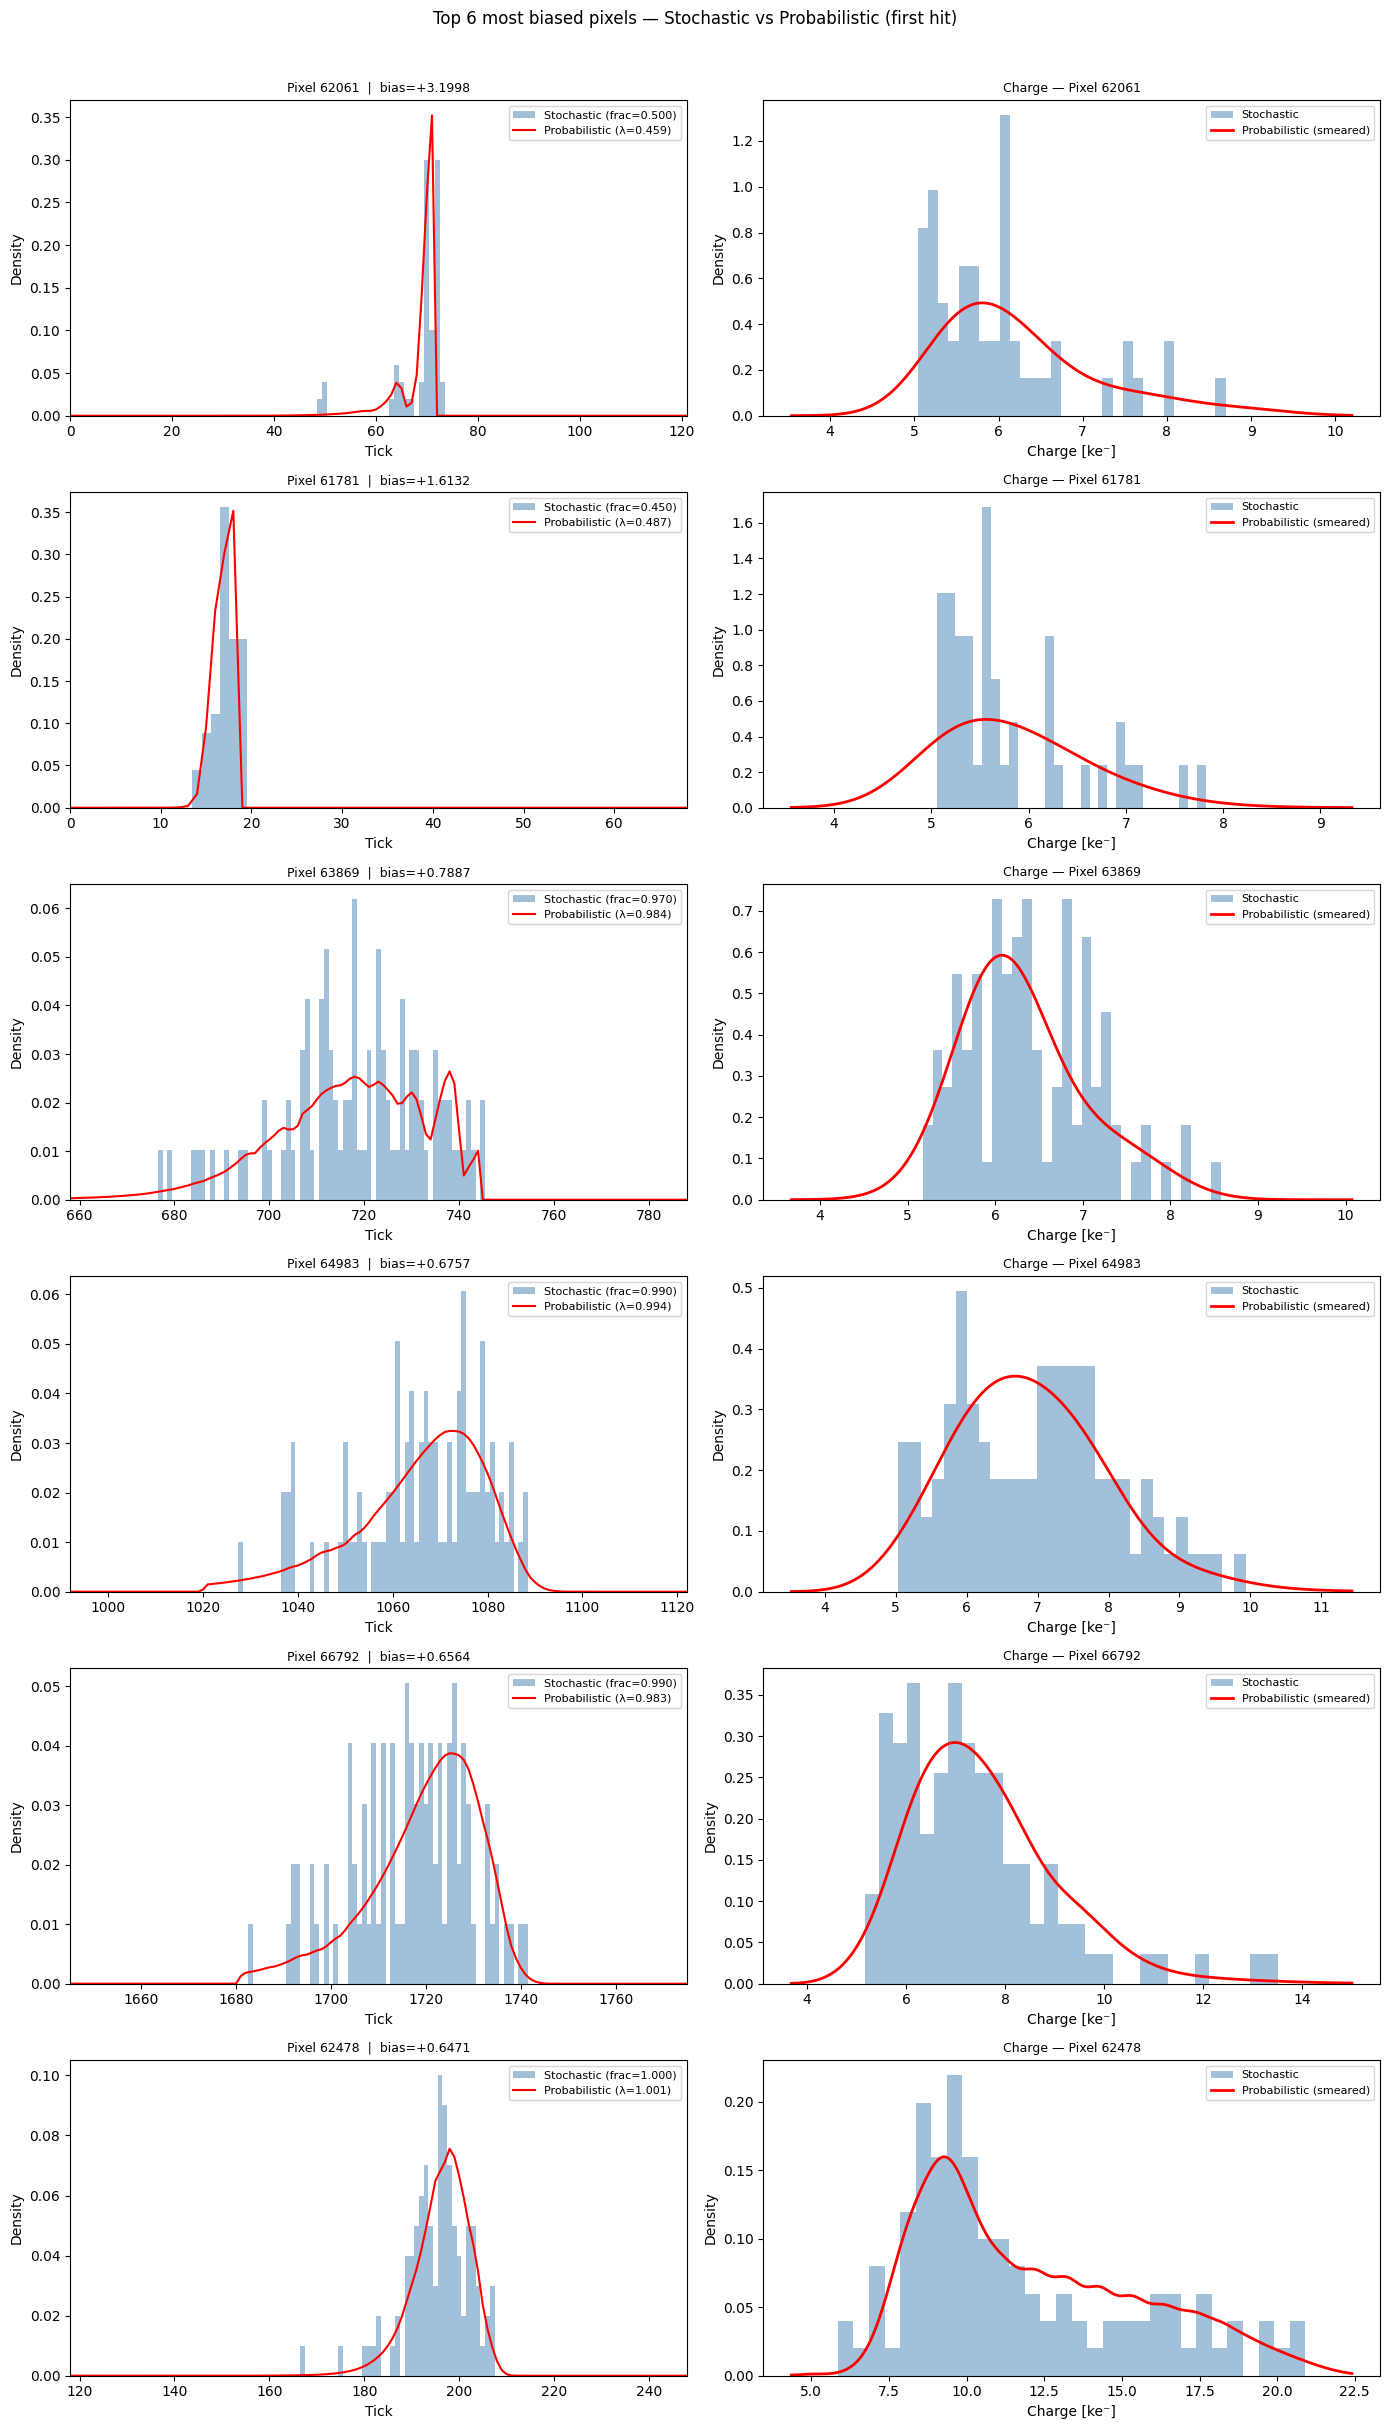

In [51]:
# ── Stochastic vs Probabilistic for the most biased pixels ───────────────────
N_TOP = 6   # how many pixels to show

# Reuse bias_per_pix from the previous cell
# top_bias_idx indexes into valid_indices
top_n_idx = np.argsort(np.abs(bias_per_pix[valid_pix_mask]))[::-1][:N_TOP]
top_n_pix = valid_indices[top_n_idx]   # absolute indices into prob_unique_pixels

fig, axes = plt.subplots(N_TOP, 2, figsize=(14, 4 * N_TOP))
if N_TOP == 1:
    axes = axes[np.newaxis, :]

from scipy.stats import norm as scipy_norm

for row, pix_i in enumerate(top_n_pix):
    pid    = int(prob_unique_pixels[pix_i])
    lam    = analytic_exphits_per_pix[pix_i]
    bias   = bias_per_pix[pix_i]

    # ── Stochastic draws for this pixel (first hit, slot 0) ──────────────
    s_ticks = bias_ticks[:, pix_i, 0]    # (N_BIAS_DRAWS,)
    s_adcs  = bias_adcs[:,  pix_i, 0]
    valid   = s_ticks < (Nticks_prob - 3)
    s_ticks_v = s_ticks[valid]
    s_adcs_v  = s_adcs[valid]
    hit_frac  = valid.mean()

    # ── Probabilistic distributions for this pixel ────────────────────────
    p_prob = p_nom_np[pix_i]                 # (Nticks,) normalised hit probs
    p_tick = p_prob / max(p_prob.sum(), 1e-30)
    p_charge_vals = q_nom_np[pix_i]          # expected charge at each tick (ke-)

    # ── Left panel: tick distributions ────────────────────────────────────
    ax = axes[row, 0]
    tick_bins = np.arange(0, Nticks_prob + 1) - 0.5

    if len(s_ticks_v) > 0:
        ax.hist(s_ticks_v, bins=tick_bins, density=True, alpha=0.5,
                color='steelblue', label=f'Stochastic (frac={hit_frac:.3f})')

    ax.plot(np.arange(Nticks_prob), p_tick, 'r-', lw=1.5,
            label=f'Probabilistic (λ={lam:.3f})')

    # Zoom ± 200 ticks around peak
    peak_t = int(np.argmax(p_prob)) if p_prob.max() > 0 else Nticks_prob // 2
    ax.set_xlim(max(0, peak_t - 80), min(Nticks_prob, peak_t + 50))

    ax.set_title(f'Pixel {pid}  |  bias={bias:+.4f}', fontsize=9)
    ax.set_xlabel('Tick')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # ── Right panel: charge distributions ─────────────────────────────────
    ax = axes[row, 1]

    if len(s_adcs_v) > 0:
        s_charge = np.array(adc2charge(jnp.array(s_adcs_v.astype(float)), current_params))
        ax.hist(s_charge, bins=30, density=True, alpha=0.5,
                color='steelblue', label='Stochastic')
    else:
        s_charge = np.array([])

    # Probabilistic = tick-weighted Gaussian mixture (same as Section 2 plot)
    weights   = p_tick   # (Nticks,)
    q_min = (s_charge.min() if len(s_charge) else p_charge_vals.min()) - 3 * sigma_ke
    q_max = (s_charge.max() if len(s_charge) else p_charge_vals.max()) + 3 * sigma_ke
    q_vals = np.linspace(q_min, q_max, 300)

    mixture_pdf = np.sum(
        weights[:, None] * scipy_norm.pdf(q_vals[None, :],
                                          loc=p_charge_vals[:, None],
                                          scale=sigma_ke),
        axis=0
    )
    ax.plot(q_vals, mixture_pdf, 'r-', lw=2, label='Probabilistic (smeared)')

    ax.set_title(f'Charge — Pixel {pid}', fontsize=9)
    ax.set_xlabel('Charge [ke⁻]')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle(f'Top {N_TOP} most biased pixels — Stochastic vs Probabilistic (first hit)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
### Cross-check: Fake-stochastic drawn from probabilistic distribution

**Idea**: Generate "fake" stochastic draws by sampling ticks directly from `hit_prob[pix, 0, :]`
and charges from `N(q_expected(t), σ_noise)`. These draws are, by construction, perfectly consistent
with the probabilistic model.

If the **fake-stochastic scan** is unbiased (minimum at nominal kb) but the **real stochastic scan**
is biased → the bias comes from a residual stochastic/probabilistic distribution mismatch.

If **both** are biased → the bias is intrinsic to the loss formulation (e.g. Jensen's inequality,
asymmetry in the charge Gaussian, or the expected-hits term).

Generating 500 fake-stochastic draws (vmapped)...
Done. Shape: (500, 128)


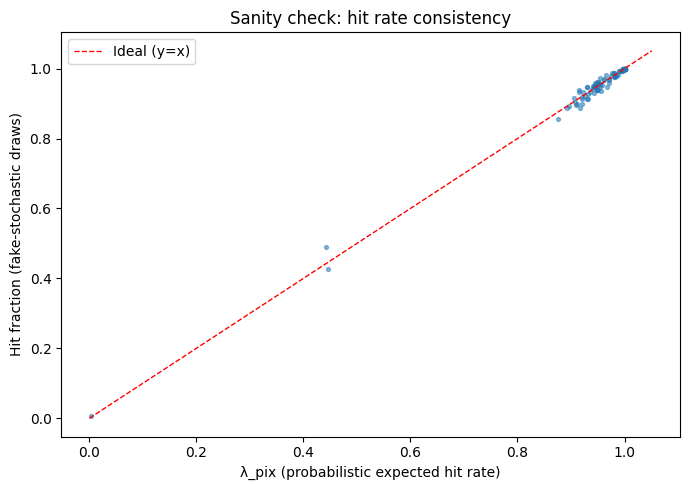

In [11]:
# ── Generate fake-stochastic draws from the probabilistic model ───────────────
# Sampling procedure per pixel (first hit only):
#   1. has_hit[pix] ~ Bernoulli(λ_pix)      where λ_pix = Σ_t exp(hit_prob[pix, 0, t])
#   2. if has_hit:  t_drawn ~ Categorical(exp(hit_prob[pix, 0, :]) / λ_pix)
#   3. if has_hit:  q_drawn ~ N(q_expected[pix, t_drawn], UNCORRELATED_NOISE)
#   4. if no hit:   tick = Nticks_prob (sentinel for "invalid / no hit")
#
# NOTE: for pixels where λ_pix > 1 the Bernoulli approximation slightly underestimates
# the hit probability (Poisson vs Bernoulli). This is typically a small correction.

N_FAKE = 500   # number of fake draws (match real stochastic scan for fair comparison)

lp0      = jnp.array(prob_pred['hit_prob'][:, 0, :])   # (Npix, Nticks) log-intensities
adc0     = jnp.array(prob_pred['adcs_distrib'][:, 0, :])  # (Npix, Nticks) expected ADC
lam_pix  = jnp.sum(jnp.exp(lp0), axis=1)               # (Npix,)

# Charge scale for noise injection: ADC -> ke-
# Estimate as adc2charge(1 ADC) to get the linear factor
adc_scale_ke = float(adc2charge(jnp.ones(1), current_params)[0])   # ke- per ADC count
sigma_adc    = sigma_ke / adc_scale_ke                              # noise in ADC units

@jax.jit
def sample_one_fake_draw(key):
    """Returns ticks (Npix,) and adcs (Npix,) for one fake draw."""
    key_bern, key_tick_base, key_noise = jax.random.split(key, 3)
    Npix = lp0.shape[0]

    # Bernoulli hit existence
    u       = jax.random.uniform(key_bern, shape=(Npix,))
    has_hit = u < lam_pix

    # Tick sampling: categorical over log-intensity logits, vmapped over pixels
    tick_keys  = jax.random.split(key_tick_base, Npix)
    drawn_ticks = jax.vmap(
        lambda logits, k: jax.random.categorical(k, logits)
    )(lp0, tick_keys)                                   # (Npix,)

    # Expected ADC at drawn tick + Gaussian noise
    drawn_adcs = adc0[jnp.arange(Npix), drawn_ticks]   # (Npix,) expected ADC
    noise      = jax.random.normal(key_noise, shape=(Npix,)) * sigma_adc
    drawn_adcs = drawn_adcs + noise

    # Sentinel for no-hit pixels
    final_ticks = jnp.where(has_hit, drawn_ticks, Nticks_prob)
    final_adcs  = jnp.where(has_hit, drawn_adcs, jnp.zeros(Npix))
    return final_ticks, final_adcs

# Generate all draws using vmap over keys
fake_keys = jax.random.split(jax.random.PRNGKey(314), N_FAKE)

print(f"Generating {N_FAKE} fake-stochastic draws (vmapped)...")
fake_ticks_all, fake_adcs_all = jax.vmap(sample_one_fake_draw)(fake_keys)
fake_ticks_all = np.array(fake_ticks_all)  # (N_FAKE, Npix)
fake_adcs_all  = np.array(fake_adcs_all)   # (N_FAKE, Npix)
print(f"Done. Shape: {fake_ticks_all.shape}")

# Sanity check: hit fraction per pixel should match λ_pix
hit_frac_fake = (fake_ticks_all < Nticks_prob).mean(axis=0)   # (Npix,)
lam_np = np.array(lam_pix)
valid_pix_mask_np = np.array(prob_unique_pixels) >= 0

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(lam_np[valid_pix_mask_np], hit_frac_fake[valid_pix_mask_np], s=8, alpha=0.5)
lim = max(lam_np[valid_pix_mask_np].max(), hit_frac_fake[valid_pix_mask_np].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='Ideal (y=x)')
ax.set_xlabel('λ_pix (probabilistic expected hit rate)')
ax.set_ylabel('Hit fraction (fake-stochastic draws)')
ax.set_title('Sanity check: hit rate consistency')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# ── Build target dicts for fake-stochastic draws ─────────────────────────────
# Reshape fake draws to (N_FAKE, Npix, 1) so build_target_from_draw can consume them
# (it expects (Npix, MAX_ADC_VALUES), with Nticks_prob as the invalid-tick sentinel)
fake_ticks_3d = fake_ticks_all[:, :, np.newaxis]  # (N_FAKE, Npix, 1)
fake_adcs_3d  = fake_adcs_all[:,  :, np.newaxis]   # (N_FAKE, Npix, 1)

print("Building fake-stochastic target dicts...")
fake_targets = [
    build_target_from_draw(
        jnp.array(fake_ticks_3d[k]),   # (Npix, 1)
        jnp.array(fake_adcs_3d[k]),    # (Npix, 1)
        prob_unique_pixels, current_params, Nticks_prob
    )
    for k in tqdm(range(N_FAKE), desc="Target dicts")
]
print("Done.")

# ── Scan with fake-stochastic targets (first-hit loss only) ──────────────────
# Uses param_vals / SCAN_PARAM / N_SCAN_PTS defined in Cell 23.
# strategy_1st defined in Cell 27.
fake_scan_results = np.zeros((N_SCAN_PTS, 2))   # [mean_nll, sem_nll]

print(f"Running {SCAN_PARAM} scan with {N_FAKE} fake-stochastic targets...")
for pi, pv in enumerate(tqdm(param_vals, desc=f"{SCAN_PARAM} scan (fake)")):
    test_params = current_params.replace(**{SCAN_PARAM: float(pv)})
    pred_pv     = prob_strategy.predict(test_params, tracks, track_fields, 42)

    nlls = []
    for target in fake_targets:
        nll, _ = strategy_1st.compute(test_params, pred_pv, target)
        nlls.append(float(nll))

    arr = np.array(nlls)
    fake_scan_results[pi, 0] = arr.mean()
    fake_scan_results[pi, 1] = arr.std() / np.sqrt(len(arr))

print("Done.")


Building fake-stochastic target dicts...


Target dicts: 100%|██████████| 500/500 [00:05<00:00, 95.18it/s]

Done.
Running kb scan with fake-stochastic targets...


NameError: name 'kb_vals' is not defined

NameError: name 'kb_results' is not defined

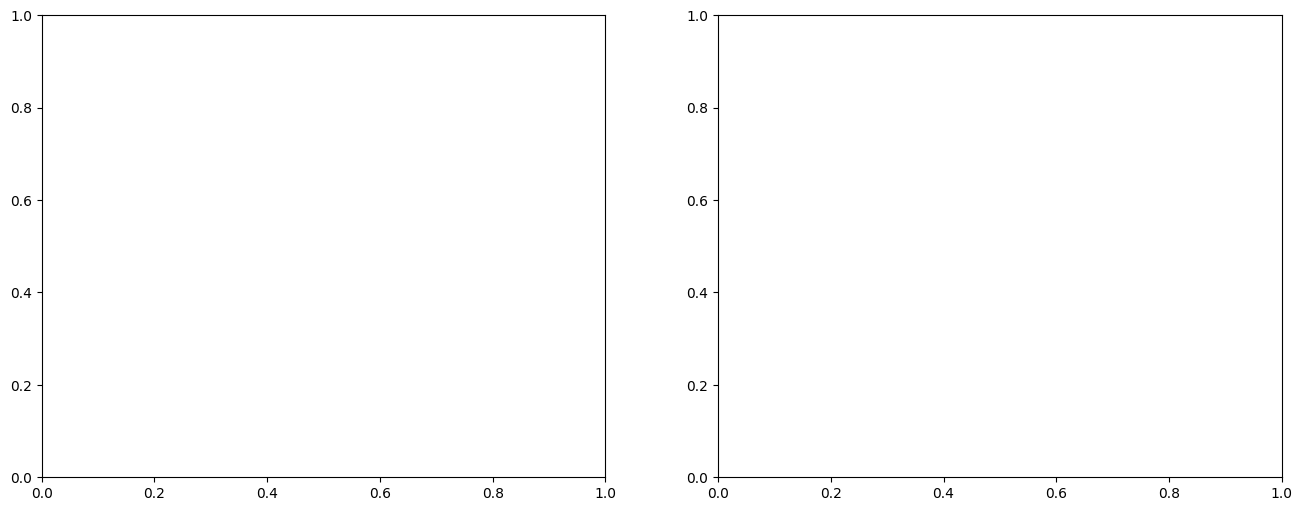

In [32]:
# ── Comparison plot: analytic vs real stochastic vs fake stochastic ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Retrieve real stochastic results (from scan in Cell 24) — first strategy key
first_key  = next(iter(scan_results))
stoch_mean = scan_results[first_key][:, 0]
stoch_sem  = scan_results[first_key][:, 1]

an_total  = np.array(analytic_results['total'])
fake_mean = fake_scan_results[:, 0]
fake_sem  = fake_scan_results[:, 1]

# ── Left: Raw NLL ─────────────────────────────────────────────────────────────
axes[0].plot(param_vals, an_total, 'k-o', lw=2, ms=5, label='Analytic expected NLL')
axes[0].errorbar(param_vals, stoch_mean, yerr=stoch_sem, fmt='b-s', lw=1.5,
                 capsize=3, label=f'Real stochastic NLL ({first_key})')
axes[0].errorbar(param_vals, fake_mean, yerr=fake_sem, fmt='r-^', lw=1.5,
                 capsize=3, label='Fake-stochastic NLL')
axes[0].axvline(param_nom, ls='--', color='gray', lw=1.2,
                label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
axes[0].set_xlabel(SCAN_PARAM)
axes[0].set_ylabel('Mean NLL')
axes[0].set_title(f'Raw NLL vs {SCAN_PARAM} — first-hit only')
axes[0].legend(fontsize=9)

# ── Right: Shifted to min=0 for shape comparison ─────────────────────────────
an_s    = an_total   - an_total.min()
stoch_s = stoch_mean - stoch_mean.min()
fake_s  = fake_mean  - fake_mean.min()

axes[1].plot(param_vals, an_s, 'k-o', lw=2, ms=5, label='Analytic expected NLL')
axes[1].fill_between(param_vals, stoch_s - stoch_sem, stoch_s + stoch_sem,
                     alpha=0.2, color='blue')
axes[1].plot(param_vals, stoch_s, 'b-s', lw=1.5, label=f'Real stochastic NLL ({first_key})')
axes[1].fill_between(param_vals, fake_s - fake_sem, fake_s + fake_sem,
                     alpha=0.2, color='red')
axes[1].plot(param_vals, fake_s, 'r-^', lw=1.5, label='Fake-stochastic NLL')
axes[1].axvline(param_nom, ls='--', color='gray', lw=1.2,
                label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
axes[1].set_xlabel(SCAN_PARAM)
axes[1].set_ylabel('NLL − min(NLL)')
axes[1].set_title(f'Shifted NLL vs {SCAN_PARAM} — shape & minimum comparison')
axes[1].legend(fontsize=9)

# Print minimum locations for all three
print("Minimum NLL locations:")
print(f"  Analytic expected :  {SCAN_PARAM} = {param_vals[np.argmin(an_total)]:.4g}")
print(f"  Real stochastic   :  {SCAN_PARAM} = {param_vals[np.argmin(stoch_mean)]:.4g}")
print(f"  Fake stochastic   :  {SCAN_PARAM} = {param_vals[np.argmin(fake_mean)]:.4g}")
print(f"  Nominal           :  {SCAN_PARAM} = {param_nom:.4g}")
print()
print("Interpretation guide:")
print("  Fake ≈ Analytic, Real ≠ Analytic → bias from stochastic/probabilistic mismatch")
print("  Fake ≈ Real ≠ Analytic           → bias from loss formulation (Jensen etc.)")
print("  All three ≈ Analytic             → no bias, system is consistent")

plt.tight_layout()
plt.show()


In [ ]:
# ── Helper: decomposed NLL scan over a configurable parameter (first-hit only) ─
# Components:
#   tick_term    = -Σ_{first hits}  hit_prob[pix, 0, t_obs]
#   charge_term  = -Σ_{first hits}  log N(q_obs; q_exp(t_obs), sigma_ke)
#   exp_hits     = Σ_{pix,t} exp(hit_prob[pix, 0, t])  ← deterministic at a given param value
#
# Key correctness notes:
#   1. Only the FIRST hit per pixel is used (occurrence index == 0)
#   2. Vectorised numpy operations instead of python loop over hits

def _first_hit_mask(pixel_ids):
    """Boolean mask that is True only for the first occurrence of each pixel_id."""
    mask = np.zeros(len(pixel_ids), dtype=bool)
    seen = set()
    for i, pid in enumerate(pixel_ids):
        if pid not in seen:
            seen.add(pid)
            mask[i] = True
    return mask


def decomposed_nll_scan(targets, param_vals, prob_strategy, tracks, track_fields,
                         current_params, Nticks_prob, sigma_ke, scan_param='kb'):
    """
    For each parameter value and each target draw, compute the decomposed NLL:
        tick_term, charge_term, exp_hits_term
    All limited to the FIRST hit per pixel (first-hit-only mode).

    Args:
        targets:         list of target dicts (stochastic or fake-stochastic draws)
        param_vals:      1-D array of parameter values to scan
        scan_param:      name of the parameter to vary (must be a field of current_params)
        ... (other args as before)

    Returns:
        dict of arrays shape (N_pts, 2) → [mean, sem] for each component.
    """
    N_pts  = len(param_vals)
    N_targ = len(targets)
    results = {c: np.zeros((N_pts, 2)) for c in ['tick', 'charge', 'exp_hits', 'total']}

    for pi, pv in enumerate(tqdm(param_vals, desc=f"{scan_param} scan", leave=False)):
        test_params = current_params.replace(**{scan_param: float(pv)})
        pred_pv     = prob_strategy.predict(test_params, tracks, track_fields, 42)

        # First-hit slot only
        hp_test  = np.array(pred_pv['hit_prob'][:, 0, :])        # (Npix, Nticks) log-probs
        adc_test = np.array(pred_pv['adcs_distrib'][:, 0, :])    # (Npix, Nticks) expected ADC
        q_test   = np.array(adc2charge(jnp.array(adc_test.ravel()), test_params)
                            ).reshape(adc_test.shape)             # (Npix, Nticks) ke-
        sim_pix  = np.array(pred_pv['unique_pixels'])             # (Npix,) sorted

        exp_hits_val = float(np.sum(np.exp(hp_test)))

        tick_vals, charge_vals, total_vals = [], [], []

        for target in targets:
            tgt_pix   = np.array(target.get('pixel_id', target.get('hit_pixels')))
            tgt_ticks = np.array(target['ticks']).astype(int)
            tgt_q     = np.array(adc2charge(jnp.array(target['adcs'].ravel()), test_params))

            # ── Filter 1: first hit per pixel only ────────────────────────────
            is_first   = _first_hit_mask(tgt_pix)

            # ── Filter 2: pixel must exist in simulation, tick must be valid ──
            pix_idx    = np.searchsorted(sim_pix, tgt_pix)
            pix_idx    = np.clip(pix_idx, 0, len(sim_pix) - 1)
            pix_match  = (sim_pix[pix_idx] == tgt_pix) & (tgt_pix >= 0)
            tick_ok    = tgt_ticks < (Nticks_prob - 3)

            valid = is_first & pix_match & tick_ok

            vi = np.where(valid)[0]
            if len(vi) > 0:
                pi_v     = pix_idx[vi]
                t        = tgt_ticks[vi]
                q_obs    = tgt_q[vi]
                log_p_t  = hp_test[pi_v, t]
                q_exp    = q_test[pi_v, t]
                log_p_q  = (-0.5 * ((q_obs - q_exp) / sigma_ke)**2
                             - 0.5 * np.log(2 * np.pi * sigma_ke**2))
                tick_nll   = -float(log_p_t.sum())
                charge_nll = -float(log_p_q.sum())
            else:
                tick_nll = charge_nll = 0.0

            tick_vals.append(tick_nll)
            charge_vals.append(charge_nll)
            total_vals.append(tick_nll + charge_nll + exp_hits_val)

        for key, arr in [('tick',     tick_vals),
                         ('charge',   charge_vals),
                         ('exp_hits', [exp_hits_val] * N_targ),
                         ('total',    total_vals)]:
            a = np.array(arr)
            results[key][pi, 0] = a.mean()
            results[key][pi, 1] = a.std() / np.sqrt(len(a))

    return results


print("Helper defined.")


Helper defined.


In [ ]:
# ── Run decomposed scans for all three methods ────────────────────────────────
scan_kwargs = dict(
    param_vals=param_vals,
    prob_strategy=prob_strategy,
    tracks=tracks,
    track_fields=track_fields,
    current_params=current_params,
    Nticks_prob=Nticks_prob,
    sigma_ke=sigma_ke,
    scan_param=SCAN_PARAM,
)

print(f"Scanning real stochastic targets ({len(scan_targets)} draws from Cell 23)...")
real_decomp = decomposed_nll_scan(scan_targets, **scan_kwargs)

print(f"Scanning fake-stochastic targets ({len(fake_targets)} draws from Cell 33)...")
fake_decomp = decomposed_nll_scan(fake_targets, **scan_kwargs)

# Analytic decomposition already computed in Cell 27 — plug directly in
analytic_decomp = {
    'tick':     np.column_stack([np.array(analytic_results['tick']),
                                  np.zeros(N_SCAN_PTS)]),
    'charge':   np.column_stack([np.array(analytic_results['charge']),
                                  np.zeros(N_SCAN_PTS)]),
    'exp_hits': np.column_stack([np.array(analytic_results['expected_hits']),
                                  np.zeros(N_SCAN_PTS)]),
    'total':    np.column_stack([np.array(analytic_results['total']),
                                  np.zeros(N_SCAN_PTS)]),
}

print("Done.")

# Quick sanity: print mean NLL at nominal value for each method and component
nom_i = np.argmin(np.abs(param_vals - param_nom))
print(f"\nSanity at {SCAN_PARAM}={param_vals[nom_i]:.4g}  (nominal={param_nom:.4g}):")
print(f"{'Component':<14} {'Analytic':>12} {'Real stoch':>12} {'Fake stoch':>12}")
for comp in ['tick', 'charge', 'exp_hits', 'total']:
    a = analytic_decomp[comp][nom_i, 0]
    r = real_decomp[comp][nom_i, 0]
    f = fake_decomp[comp][nom_i, 0]
    print(f"  {comp:<12}  {a:>12.4f}  {r:>12.4f}  {f:>12.4f}")


Scanning real stochastic targets (100 draws from Cell 23)...


Scanning fake-stochastic targets (500 draws from Cell 33)...


Done.

Sanity at nominal kb=0.0484:
Component          Analytic   Real stoch   Fake stoch
  tick              358.0129      378.0585      357.9930
  charge             20.5292       65.0135       20.5233
  exp_hits           92.9175       92.9174       92.9176
  total             471.4596      535.9894      471.4338


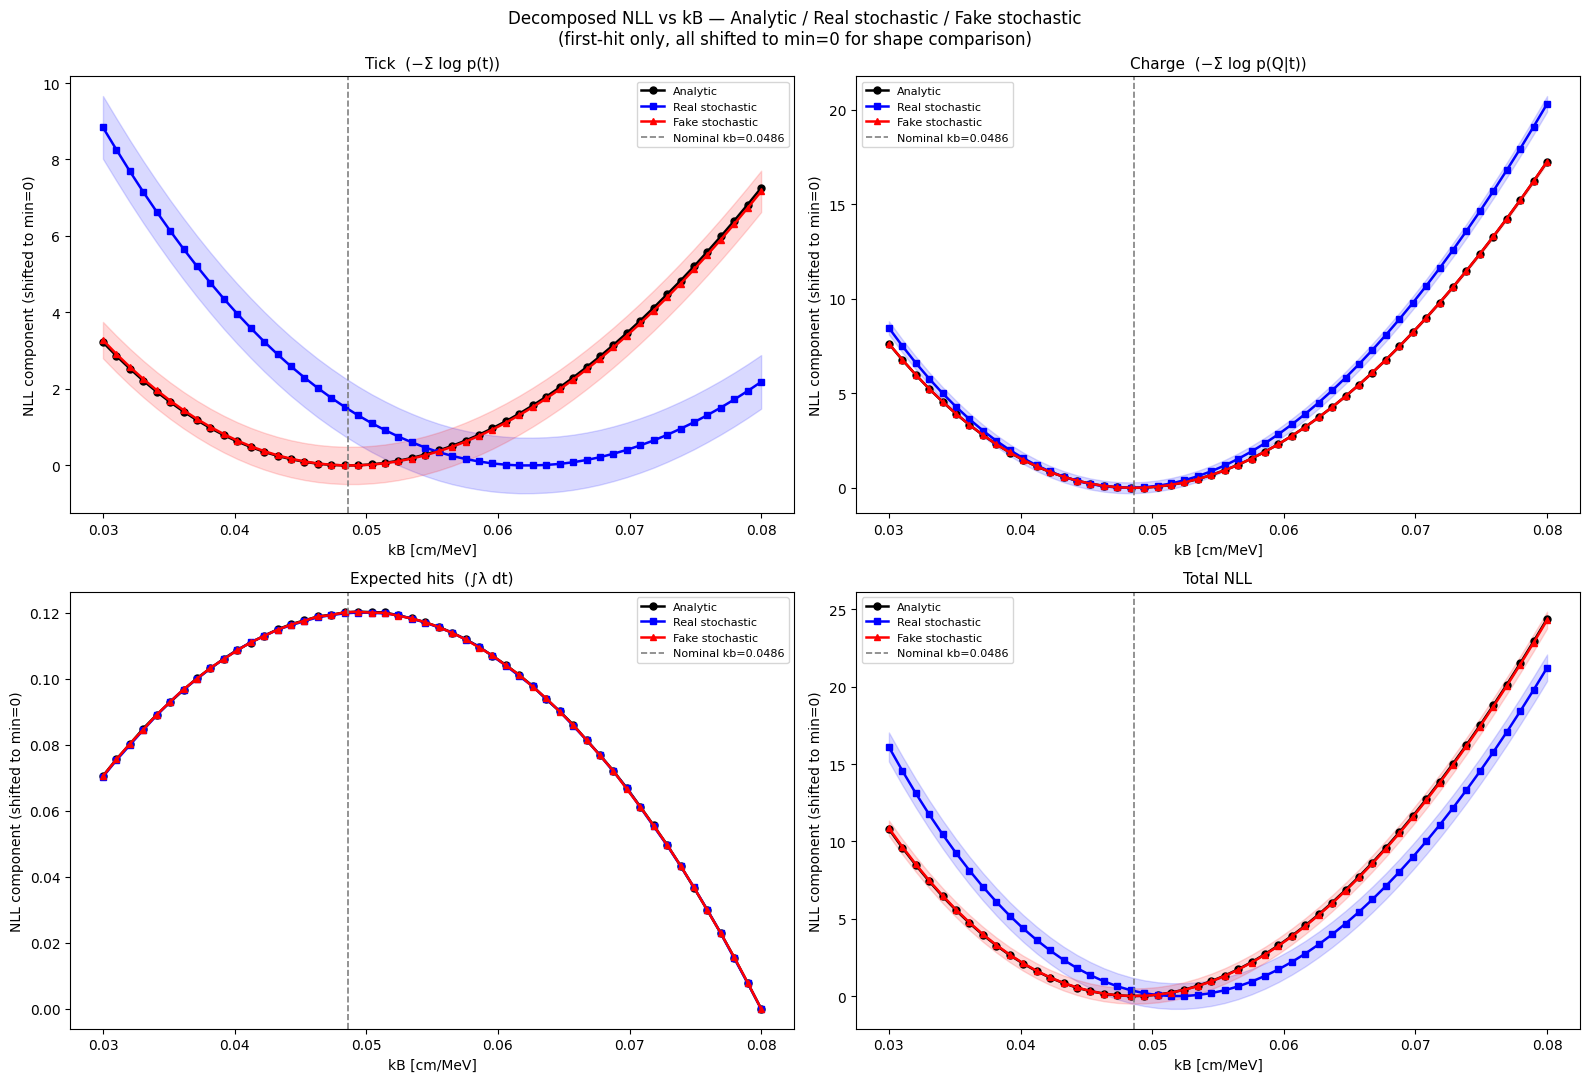


Component                   Analytic    Real stoch    Fake stoch     Nominal
--------------------------------------------------------------------------
Tick  (−Σ log p(t))           0.0484        0.0616        0.0484      0.0486
Charge  (−Σ log p(Q|t))        0.0484        0.0484        0.0484      0.0486
Expected hits  (∫λ dt)        0.0800        0.0800        0.0800      0.0486
Total NLL                     0.0484        0.0524        0.0484      0.0486


In [ ]:
# ── Plot: component-wise comparison for all three methods ─────────────────────
components  = ['tick', 'charge', 'exp_hits', 'total']
comp_labels = ['Tick  (−Σ log p(t))', 'Charge  (−Σ log p(Q|t))',
               'Expected hits  (∫λ dt)', 'Total NLL']

methods = {
    'Analytic':        (analytic_decomp, 'k', 'o', '-'),
    'Real stochastic': (real_decomp,     'b', 's', '-'),
    'Fake stochastic': (fake_decomp,     'r', '^', '-'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, comp, clabel in zip(axes.flat, components, comp_labels):
    for label, (data, color, marker, ls) in methods.items():
        mean   = data[comp][:, 0]
        sem    = data[comp][:, 1]
        mean_s = mean - mean.min()   # shift to min=0 for shape comparison
        ax.plot(param_vals, mean_s, color=color, marker=marker, ls=ls,
                lw=1.8, ms=5, label=label)
        if sem.max() > 0:
            ax.fill_between(param_vals, mean_s - sem, mean_s + sem,
                            alpha=0.15, color=color)

    ax.axvline(param_nom, ls='--', color='gray', lw=1.2,
               label=f'Nominal {SCAN_PARAM}={param_nom:.4g}')
    ax.set_xlabel(SCAN_PARAM)
    ax.set_ylabel('NLL component (shifted to min=0)')
    ax.set_title(clabel, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle(f'Decomposed NLL vs {SCAN_PARAM} — Analytic / Real stochastic / Fake stochastic\n'
             '(first-hit only, all shifted to min=0 for shape comparison)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Print min locations per component per method
print(f"\n{'Component':<22}  {'Analytic':>12}  {'Real stoch':>12}  {'Fake stoch':>12}  {'Nominal':>10}")
print("-" * 74)
for comp, clabel in zip(components, comp_labels):
    a_min = param_vals[np.argmin(analytic_decomp[comp][:, 0])]
    r_min = param_vals[np.argmin(real_decomp[comp][:, 0])]
    f_min = param_vals[np.argmin(fake_decomp[comp][:, 0])]
    print(f"{clabel:<22}  {a_min:>12.4g}  {r_min:>12.4g}  {f_min:>12.4g}  {param_nom:>10.4g}")


---
## Section 4 — Probabilistic vs Stochastic Bias Diagnosis

This section systematically diagnoses *where* and *why* the probabilistic estimate disagrees with the stochastic simulation.

**Five diagnostic plots:**
1. **λ calibration** — prob hit-rate per pixel vs actual stochastic hit-rate (master bias check)
2. **Expected-tick bias** — prob mean tick vs stochastic mean tick per pixel
3. **Tick distribution overlays** — full p(t) curves for the most biased pixels
4. **Charge residuals vs tick** — (q_stoch − q_prob) as a function of tick position
5. **Jensen's inequality contribution** — per-pixel contribution to analytic vs stochastic NLL gap

All plots use variables from Sections 2 & 3 (`prob_pred`, `stoch_ticks`, `stoch_adcs`, `prob_wfs`).

In [8]:
# ── Sec 4 setup: per-pixel hit-rate statistics from stochastic draws ──────────
# stoch_ticks shape: (N_STOCH, Npix, MAX_ADC_VALUES)
# We work with the FIRST hit slot only (slot 0) for clean first-hit analysis.

import scipy.stats

Nticks_wf  = prob_wfs.shape[1]                   # waveform time axis length
stoch_t0   = np.array(stoch_ticks[:, :, 0])      # (N_STOCH, Npix) first-hit tick
stoch_a0   = np.array(stoch_adcs[:, :, 0])       # (N_STOCH, Npix) first-hit ADC
upix       = np.array(prob_unique_pixels)         # (Npix,)

# Boolean masks
valid_tick = (stoch_t0 < Nticks_wf - 3)          # True when a hit actually fired
valid_pix  = (upix >= 0)                          # True for non-padding pixels

# ── Per-pixel statistics from stochastic draws ───────────────────────────────
stoch_hit_rate = valid_tick.mean(axis=0)          # (Npix,)  fraction of draws with hit

stoch_mean_tick = np.full(len(upix), np.nan)
stoch_std_tick  = np.full(len(upix), np.nan)
for pix_i in range(len(upix)):
    fired_ticks = stoch_t0[valid_tick[:, pix_i], pix_i].astype(float)
    if len(fired_ticks) > 5:
        stoch_mean_tick[pix_i] = fired_ticks.mean()
        stoch_std_tick[pix_i]  = fired_ticks.std()

# ── Probabilistic λ and expected tick per pixel ──────────────────────────────
hp0      = np.array(jnp.exp(prob_pred['hit_prob'][:, 0, :]))  # (Npix, Nticks)
lam      = hp0.sum(axis=1)                                     # (Npix,) prob hit rate
ticks_ax = np.arange(hp0.shape[1])
prob_mean_tick = np.where(
    lam > 1e-9,
    (hp0 * ticks_ax[None, :]).sum(axis=1) / np.maximum(lam, 1e-9),
    np.nan
)

# ── Prob expected charge per (pixel, tick) in ke- ────────────────────────────
q0_prob      = np.array(adc2charge(prob_pred['adcs_distrib'][:, 0, :], current_params))  # (Npix, Nticks)
sigma_ke_val = ProbabilisticLossStrategy(first_hit_only=True).sigma_charge / 1000.0

print(f"Valid pixels         : {valid_pix.sum()}")
print(f"Mean stoch hit rate  : {stoch_hit_rate[valid_pix].mean():.4f}")
print(f"Mean prob λ          : {lam[valid_pix].mean():.4f}")
print(f"Max |λ − hit_rate|   : {np.abs(lam[valid_pix] - stoch_hit_rate[valid_pix]).max():.5f}")

Valid pixels         : 94
Mean stoch hit rate  : 0.9487
Mean prob λ          : 0.9430
Max |λ − hit_rate|   : 0.08993


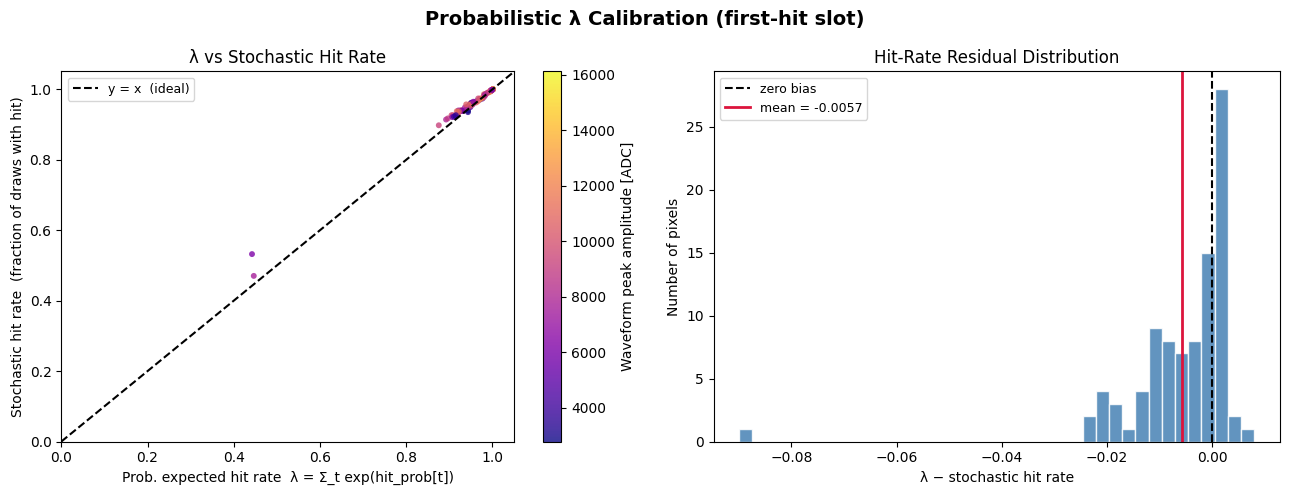

Bias:  mean(λ−rate) = -0.0057   std = 0.0113   max|bias| = 0.0899


In [9]:
# ── Plot 1: λ calibration — prob expected hit rate vs stochastic hit rate ─────
# A perfectly calibrated model falls on y=x.
# Colours show waveform peak amplitude to reveal if bias correlates with signal strength.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Probabilistic λ Calibration (first-hit slot)', fontsize=14, fontweight='bold')

mask    = valid_pix & (stoch_hit_rate > 0.01)
lam_m   = lam[mask]
rate_m  = stoch_hit_rate[mask]
wf_peak = np.array(prob_wfs[mask]).max(axis=1)

ax = axes[0]
sc = ax.scatter(lam_m, rate_m, c=wf_peak, cmap='plasma', s=18, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax, label='Waveform peak amplitude [ADC]')
lims = [0, max(lam_m.max(), rate_m.max()) * 1.05]
ax.plot(lims, lims, 'k--', lw=1.5, label='y = x  (ideal)')
ax.set_xlabel('Prob. expected hit rate  λ = Σ_t exp(hit_prob[t])')
ax.set_ylabel('Stochastic hit rate  (fraction of draws with hit)')
ax.set_title('λ vs Stochastic Hit Rate')
ax.legend(fontsize=9); ax.set_xlim(lims); ax.set_ylim(lims)

resid = lam_m - rate_m
ax = axes[1]
bins = np.linspace(resid.min(), resid.max(), 40)
ax.hist(resid, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0,            color='black',   lw=1.5, ls='--', label='zero bias')
ax.axvline(resid.mean(), color='crimson', lw=2,           label=f'mean = {resid.mean():.4f}')
ax.set_xlabel('λ − stochastic hit rate'); ax.set_ylabel('Number of pixels')
ax.set_title('Hit-Rate Residual Distribution'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"Bias:  mean(λ−rate) = {resid.mean():.4f}   std = {resid.std():.4f}   max|bias| = {np.abs(resid).max():.4f}")

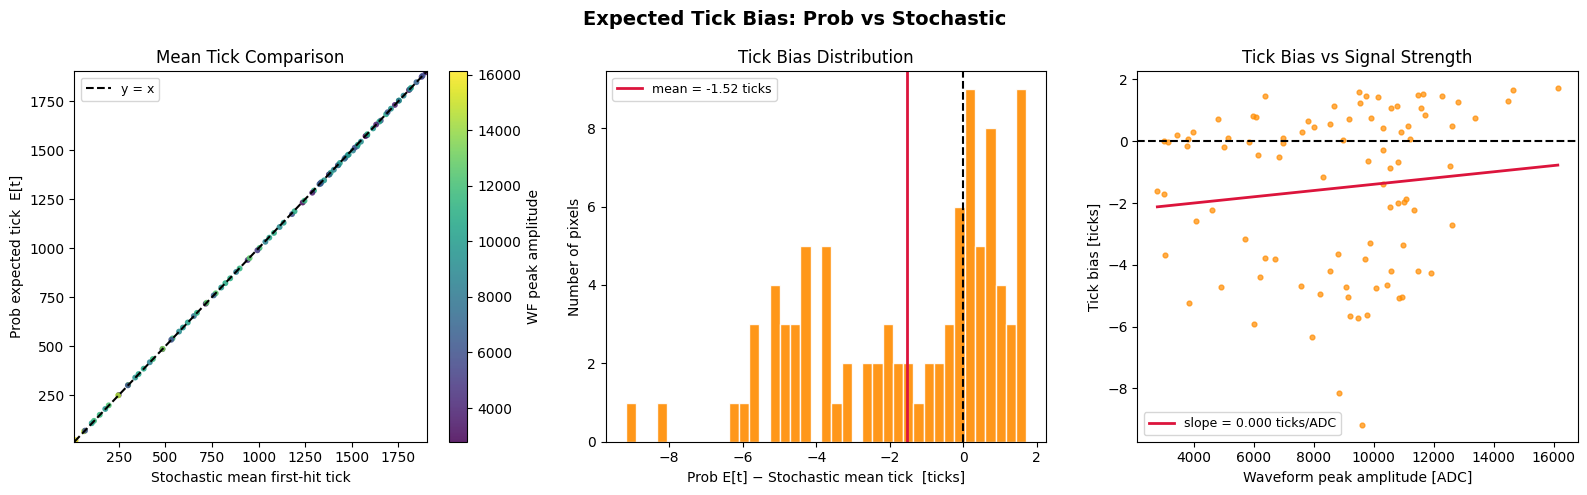

Tick bias:  mean = -1.52  std = 2.60 ticks


In [65]:
# ── Plot 2: Expected-tick bias per pixel ──────────────────────────────────────
# Compare prob E[t] = Σ_t t·p(t)/λ  vs  stochastic mean first-hit tick.
# A shift indicates the threshold-crossing density peaks at the wrong time.
# Correlation with amplitude reveals amplitude-dependent timing bias.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Expected Tick Bias: Prob vs Stochastic', fontsize=14, fontweight='bold')

mask2     = valid_pix & (stoch_hit_rate > 0.05)
pt        = prob_mean_tick[mask2]
st        = stoch_mean_tick[mask2]
wfp       = np.array(prob_wfs[mask2]).max(axis=1)
tick_bias = pt - st   # positive → prob fires earlier than stochastic

ax = axes[0]
sc = ax.scatter(st, pt, c=wfp, cmap='viridis', s=18, alpha=0.85, linewidths=0)
plt.colorbar(sc, ax=ax, label='WF peak amplitude')
lim2 = [min(st.min(), pt.min()) - 5, max(st.max(), pt.max()) + 5]
ax.plot(lim2, lim2, 'k--', lw=1.5, label='y = x')
ax.set_xlabel('Stochastic mean first-hit tick'); ax.set_ylabel('Prob expected tick  E[t]')
ax.set_title('Mean Tick Comparison')
ax.legend(fontsize=9); ax.set_xlim(lim2); ax.set_ylim(lim2)

ax = axes[1]
bins = np.linspace(np.nanmin(tick_bias), np.nanmax(tick_bias), 40)
ax.hist(tick_bias[np.isfinite(tick_bias)], bins=bins, color='darkorange', edgecolor='white', alpha=0.9)
ax.axvline(0,                color='black',   lw=1.5, ls='--')
ax.axvline(np.nanmean(tick_bias), color='crimson', lw=2,
           label=f'mean = {np.nanmean(tick_bias):.2f} ticks')
ax.set_xlabel('Prob E[t] − Stochastic mean tick  [ticks]'); ax.set_ylabel('Number of pixels')
ax.set_title('Tick Bias Distribution'); ax.legend(fontsize=9)

ax = axes[2]
fin = np.isfinite(tick_bias)
ax.scatter(wfp[fin], tick_bias[fin], s=12, alpha=0.7, c='darkorange')
ax.axhline(0, color='black', lw=1.5, ls='--')
z = np.polyfit(wfp[fin], tick_bias[fin], 1)
xline = np.linspace(wfp.min(), wfp.max(), 100)
ax.plot(xline, np.polyval(z, xline), 'crimson', lw=2,
        label=f'slope = {z[0]:.3f} ticks/ADC')
ax.set_xlabel('Waveform peak amplitude [ADC]'); ax.set_ylabel('Tick bias [ticks]')
ax.set_title('Tick Bias vs Signal Strength'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"Tick bias:  mean = {np.nanmean(tick_bias):.2f}  std = {np.nanstd(tick_bias):.2f} ticks")

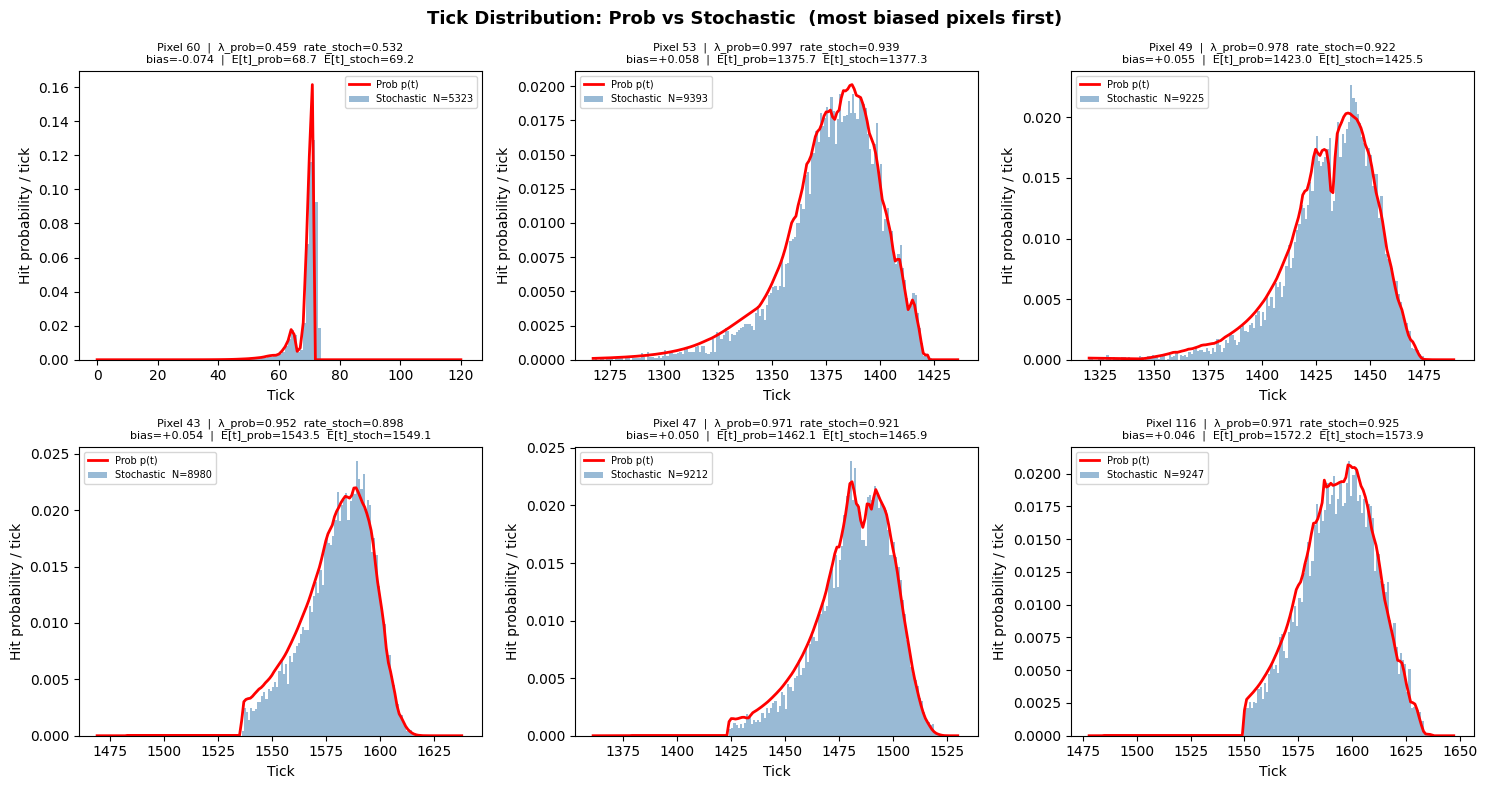

In [67]:
# ── Plot 3: Tick distribution overlays — most biased pixels ──────────────────
# For each pixel: show prob p(t) curve vs empirical stochastic tick histogram.
# Sorted by |λ_prob − rate_stoch| descending so the worst cases appear first.

mask3      = valid_pix & (stoch_hit_rate > 0.02)
rank_score = np.abs(lam[mask3] - stoch_hit_rate[mask3])
pix_ranked = np.where(mask3)[0][np.argsort(rank_score)[::-1]]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Tick Distribution: Prob vs Stochastic  (most biased pixels first)',
             fontsize=13, fontweight='bold')

for rank, ax in enumerate(axes.flat):
    if rank >= len(pix_ranked):
        ax.set_visible(False); continue
    pix_i = pix_ranked[rank]

    fired     = valid_tick[:, pix_i]
    hit_ticks = stoch_t0[fired, pix_i]
    if len(hit_ticks) < 5:
        ax.set_visible(False); continue

    # Window: ±120 ticks around prob intensity peak
    prob_peak_t = int(np.argmax(hp0[pix_i]))
    t_lo = max(0, prob_peak_t - 120)
    t_hi = min(hp0.shape[1], prob_peak_t + 50)
    tick_range = np.arange(t_lo, t_hi)

    hist_cnts, _ = np.histogram(hit_ticks, bins=np.arange(t_lo, t_hi + 1))
    hist_rate = hist_cnts / N_STOCH  # per-tick fraction of all draws

    ax.bar(tick_range, hist_rate, width=1, color='steelblue', alpha=0.55,
           label=f'Stochastic  N={len(hit_ticks)}', align='edge')
    ax.plot(tick_range, hp0[pix_i, t_lo:t_hi], 'r-', lw=2, label='Prob p(t)')
    ax.set_xlabel('Tick'); ax.set_ylabel('Hit probability / tick')
    ax.set_title(
        f'Pixel {pix_i}  |  λ_prob={lam[pix_i]:.3f}  rate_stoch={stoch_hit_rate[pix_i]:.3f}\n'
        f'bias={lam[pix_i]-stoch_hit_rate[pix_i]:+.3f}  |  '
        f'E[t]_prob={prob_mean_tick[pix_i]:.1f}  E[t]_stoch={stoch_mean_tick[pix_i]:.1f}',
        fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

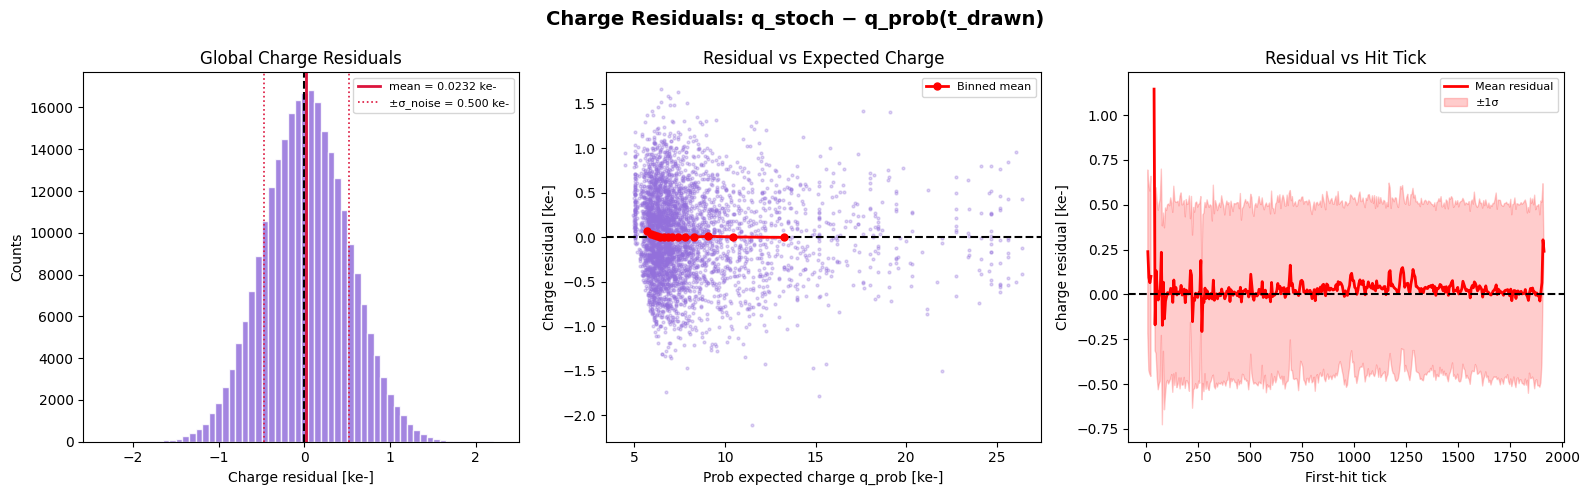

Charge residual:  mean = 0.02318 ke-   std = 0.49062 ke-


In [68]:
# ── Plot 4: Charge residuals — q_stoch − q_prob(t_drawn) ─────────────────────
# For each stochastic draw that fired at tick t, look up q_prob(t) and compute
# the residual.  Reveals systematic charge bias as a function of tick or charge.

NSAMPLE  = min(3000, N_STOCH)
rng_sel  = np.random.choice(N_STOCH, NSAMPLE, replace=False)

q_resid_vals, q_prob_vals, wf_amp_vals, tick_vals_flat = [], [], [], []

for s in rng_sel:
    for pix_i in range(len(upix)):
        if not valid_pix[pix_i]: continue
        t = int(stoch_t0[s, pix_i])
        if t >= Nticks_wf - 3 or t >= q0_prob.shape[1]: continue
        q_s = float(adc2charge(stoch_adcs[s, pix_i, 0], current_params))
        q_p = float(q0_prob[pix_i, t])
        q_resid_vals.append(q_s - q_p)
        q_prob_vals.append(q_p)
        wf_amp_vals.append(float(prob_wfs[pix_i].max()))
        tick_vals_flat.append(t)

q_resid_vals   = np.array(q_resid_vals)
q_prob_vals    = np.array(q_prob_vals)
tick_vals_flat = np.array(tick_vals_flat)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Charge Residuals: q_stoch − q_prob(t_drawn)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(q_resid_vals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(0,                   color='black',   lw=1.5, ls='--')
ax.axvline(q_resid_vals.mean(), color='crimson', lw=2,
           label=f'mean = {q_resid_vals.mean():.4f} ke-')
for s in [+1, -1]:
    ax.axvline(q_resid_vals.mean() + s*sigma_ke_val, color='crimson', lw=1.2, ls=':',
               label=f'±σ_noise = {sigma_ke_val:.3f} ke-' if s > 0 else '')
ax.set_xlabel('Charge residual [ke-]'); ax.set_ylabel('Counts')
ax.set_title('Global Charge Residuals'); ax.legend(fontsize=8)

ax = axes[1]
perm = np.random.permutation(len(q_resid_vals))[:4000]
ax.scatter(q_prob_vals[perm], q_resid_vals[perm], s=4, alpha=0.3, c='mediumpurple')
ax.axhline(0, color='black', lw=1.5, ls='--')
bins_q  = np.percentile(q_prob_vals, np.linspace(5, 95, 15))
bc      = 0.5 * (bins_q[:-1] + bins_q[1:])
bin_m   = [q_resid_vals[(q_prob_vals >= b0) & (q_prob_vals < b1)].mean()
           if ((q_prob_vals >= b0) & (q_prob_vals < b1)).sum() > 5 else np.nan
           for b0, b1 in zip(bins_q[:-1], bins_q[1:])]
ax.plot(bc, bin_m, 'r-o', lw=2, ms=5, label='Binned mean')
ax.set_xlabel('Prob expected charge q_prob [ke-]')
ax.set_ylabel('Charge residual [ke-]')
ax.set_title('Residual vs Expected Charge'); ax.legend(fontsize=8)

ax = axes[2]
bin_ticks = np.arange(0, int(tick_vals_flat.max()) + 10, 5)
bm, _, _  = scipy.stats.binned_statistic(tick_vals_flat, q_resid_vals, 'mean', bins=bin_ticks)
bs, _, _  = scipy.stats.binned_statistic(tick_vals_flat, q_resid_vals, 'std',  bins=bin_ticks)
bc_t = 0.5 * (bin_ticks[:-1] + bin_ticks[1:])
ax.plot(bc_t, bm, 'r-', lw=2, label='Mean residual')
ax.fill_between(bc_t, bm - bs, bm + bs, color='r', alpha=0.2, label='±1σ')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('First-hit tick'); ax.set_ylabel('Charge residual [ke-]')
ax.set_title('Residual vs Hit Tick'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"Charge residual:  mean = {q_resid_vals.mean():.5f} ke-   std = {q_resid_vals.std():.5f} ke-")

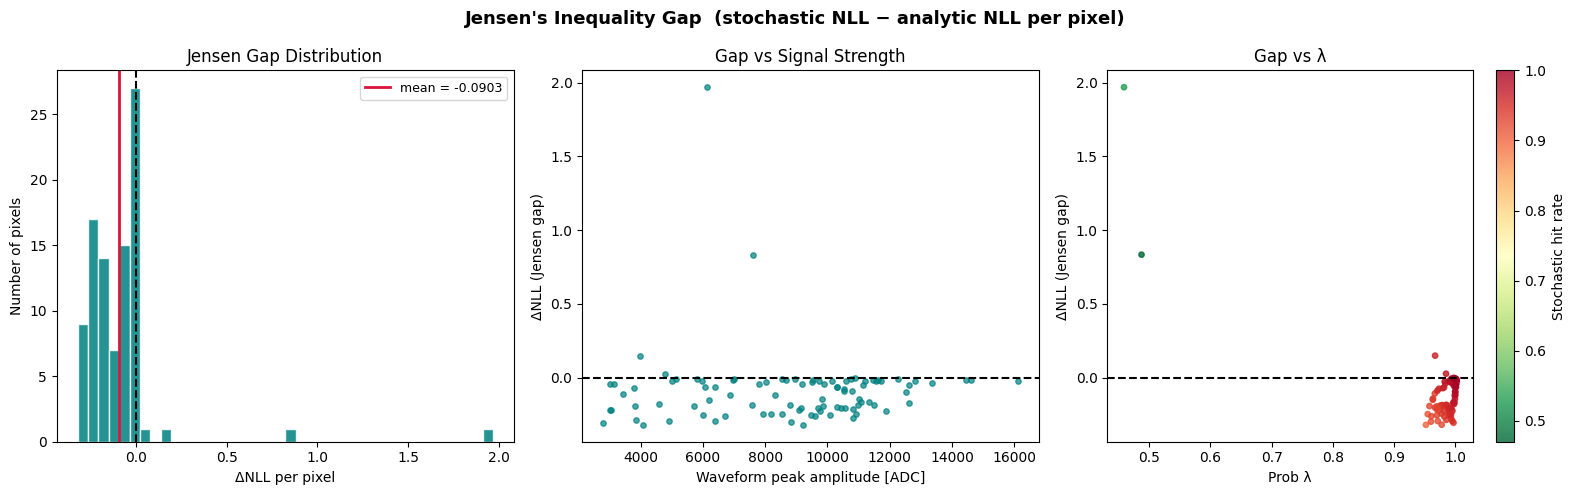

Jensen gap:  mean = -0.09033   sum = -8.4010
(positive → stochastic draws are harder to explain than analytic expectation)


In [70]:
# ── Plot 5: Jensen's inequality contribution per pixel ───────────────────────
# ΔNLL_pix = <NLL_stoch(pix)> − NLL_analytic(pix)
# NLL_analytic(pix) = H(p_nom)  + λ   (self-entropy + expected hits)
# NLL_stoch(pix)    = E_draw[-log p(t_draw)] + λ
# Positive ΔNLL → stochastic draws pay a higher average log-loss than
# the prob model's self-consistent expectation (Jensen gap).

hp0_log = np.array(prob_pred['hit_prob'][:, 0, :])  # (Npix, Nticks) log-probs
hp0_p   = np.exp(hp0_log)                           # (Npix, Nticks) probs

analytic_tick_per_pix    = -np.sum(hp0_p * hp0_log, axis=1)  # entropy
analytic_exphits_per_pix = hp0_p.sum(axis=1)                 # λ
analytic_total_per_pix   = analytic_tick_per_pix + analytic_exphits_per_pix

stoch_nll_per_pix = np.zeros(len(upix))
for pix_i in range(len(upix)):
    if not valid_pix[pix_i]: continue
    fired_i    = valid_tick[:, pix_i]
    t_i        = np.minimum(stoch_t0[:, pix_i], hp0_log.shape[1] - 1).astype(int)
    tick_nll_i = np.where(fired_i, -hp0_log[pix_i, t_i], 0.0)
    stoch_nll_per_pix[pix_i] = tick_nll_i.mean() + analytic_exphits_per_pix[pix_i]

delta_nll = stoch_nll_per_pix - analytic_total_per_pix  # (Npix,)
mask_j    = valid_pix & (stoch_hit_rate > 0.02)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Jensen's Inequality Gap  (stochastic NLL − analytic NLL per pixel)",
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(delta_nll[mask_j], bins=40, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(0,                        color='black',   lw=1.5, ls='--')
ax.axvline(delta_nll[mask_j].mean(), color='crimson', lw=2,
           label=f'mean = {delta_nll[mask_j].mean():.4f}')
ax.set_xlabel('ΔNLL per pixel'); ax.set_ylabel('Number of pixels')
ax.set_title('Jensen Gap Distribution'); ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(np.array(prob_wfs[mask_j]).max(axis=1), delta_nll[mask_j],
           s=15, alpha=0.7, c='teal')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Waveform peak amplitude [ADC]')
ax.set_ylabel('ΔNLL (Jensen gap)'); ax.set_title('Gap vs Signal Strength')

ax = axes[2]
sc = ax.scatter(lam[mask_j], delta_nll[mask_j],
                c=stoch_hit_rate[mask_j], cmap='RdYlGn_r', s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Stochastic hit rate')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Prob λ'); ax.set_ylabel('ΔNLL (Jensen gap)'); ax.set_title('Gap vs λ')

plt.tight_layout(); plt.show()
print(f"Jensen gap:  mean = {delta_nll[mask_j].mean():.5f}   sum = {delta_nll[mask_j].sum():.4f}")
print("(positive → stochastic draws are harder to explain than analytic expectation)")

---
### Section 4 — Interpretation Guide

| Plot | What it diagnoses | Key signatures |
|------|------------------|----------------|
| **1 · λ calibration** | Overall hit-rate accuracy of the Gaussian threshold model | Points above y=x → prob overestimates rate; below → underestimates |
| **2 · Tick bias** | Timing accuracy of p(t) | Systematic mean shift → wrong peak timing; slope vs amplitude → amplitude-dependent bias |
| **3 · Distributions** | Shape of p(t) per pixel | Prob curve narrower/broader → Gaussian approximation has wrong width at threshold |
| **4 · Charge residuals** | Systematic charge mis-estimation | Non-zero mean → offset in `adcs_distrib`; trend vs tick → wrong charge shape along waveform |
| **5 · Jensen gap** | Irreducible bias from E[log p] ≠ log E[p] | Positive ΔNLL at high-λ pixels → non-linearity of −log dominates near threshold |

**Most likely root causes (check in order):**
1. **λ calibration bias (Plot 1)** — If prob systematically overestimates the hit rate, the Gaussian approximation for the threshold probability is too wide relative to the actual reset noise
2. **Timing shift (Plot 2)** — A positive tick bias means `adcs_distrib` peaks slightly before the actual stochastic peak; check the cumulative integration in `get_adc_values_average_noise`
3. **Charge offset (Plot 4)** — A non-zero mean residual indicates `adcs_distrib` systematically over/under-estimates the charge collected per tick (typically from averaging before nonlinear digitization)
4. **Jensen gap (Plot 5)** — Even a perfectly calibrated prob model has an irreducible Jensen gap ≈ ½ Var[−log p(T)] which grows for narrow, high-intensity peaks